<center><div style="background-color: brown"><h1><font color=white face="georgia">Importing Libraries

In [1]:
# Data Preprocessing
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from bs4 import BeautifulSoup
import re
from collections import Counter


# Data Visualization Modules
import matplotlib.pyplot as plt
import seaborn as sns

# Text Preprocessing
import nltk
from wordcloud import WordCloud
import re
from nltk.corpus import stopwords
from nltk import sent_tokenize
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

# Model Building and Training (ML models)
import time
from sklearn.model_selection import KFold
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from xgboost import XGBClassifier, XGBRFClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC

# Neural Networks (DL model)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# Evaluation Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score

#Saving trained models
import pickle 

<center><div style="background-color: brown"><h1><font color=white face="georgia">Importing Data

In [2]:
spam_data = pd.read_csv('datasets/spam_assassin.csv')
spam_data

,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0
...,...,...
5791,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,0
5792,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,0
5793,Received: from hq.pro-ns.net (localhost [127.0...,1
5794,From razor-users-admin@lists.sourceforge.net T...,0


<center><div style="background-color: brown"><h1><font color=white face="georgia">EDA

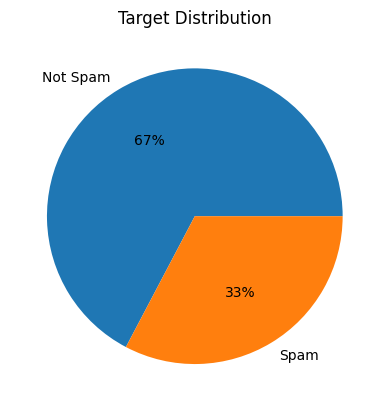

In [3]:
plt.pie(x=[spam_data['target'].value_counts()[0], spam_data['target'].value_counts()[1]], 
        labels=['Not Spam', 'Spam'], autopct='%.f%%')
plt.title('Target Distribution')
plt.show()

<h3><font face=verdona> As per the visualtization the data is fairly distributed for this specific Task

In [4]:
spam_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5796 entries, 0 to 5795
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5796 non-null   object
 1   target  5796 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 90.7+ KB


<h3><font color=yellow face=verdona><center> No null records

<center><div style="background-color: brown"><h2><font color=white face="georgia">Data cleaning

In [5]:
for i in range(5):
    print(f'\nemail : {i}\n {spam_data['text'][i]}')


email : 0
 From ilug-admin@linux.ie Mon Jul 29 11:28:02 2002 Return-Path: <ilug-admin@linux.ie> Delivered-To: yyyy@localhost.netnoteinc.com Received: from localhost (localhost [127.0.0.1]) by phobos.labs.netnoteinc.com (Postfix) with ESMTP id A13D94414F for <jm@localhost>; Mon, 29 Jul 2002 06:25:11 -0400 (EDT) Received: from phobos [127.0.0.1] by localhost with IMAP (fetchmail-5.9.0) for jm@localhost (single-drop); Mon, 29 Jul 2002 11:25:11 +0100 (IST) Received: from lugh.tuatha.org (root@lugh.tuatha.org [194.125.145.45]) by dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g6RHn7i17130 for <jm-ilug@jmason.org>; Sat, 27 Jul 2002 18:49:07 +0100 Received: from lugh (root@localhost [127.0.0.1]) by lugh.tuatha.org (8.9.3/8.9.3) with ESMTP id SAA25016; Sat, 27 Jul 2002 18:45:03 +0100 X-Authentication-Warning: lugh.tuatha.org: Host root@localhost [127.0.0.1] claimed to be lugh Received: from mail1.mail.iol.ie (mail1.mail.iol.ie [194.125.2.192]) by lugh.tuatha.org (8.9.3/8.9.3) with ESMTP id

<h3><font face=verdona> The "text" feature seems to have html tags which need to be parsed

In [6]:
def parse_text(data, col):
        for index, text in enumerate(data[col]):
                try : 
                        soup = BeautifulSoup(data[col][index], 'lxml')
                        parsed_text = soup.text.strip()
                except Exception as ex :
                        parsed_text = ""
                finally :
                        data.loc[index, col] = parsed_text
        return data

In [7]:
spam_data = parse_text(spam_data, 'text')
spam_data

,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0
...,...,...
5791,From ilug-admin@linux.ie Mon Jul 22 18:12:45 2...,0
5792,From fork-admin@xent.com Mon Oct 7 20:37:02 20...,0
5793,Received: from hq.pro-ns.net (localhost [127.0...,1
5794,From razor-users-admin@lists.sourceforge.net T...,0


<h3><font color=yellow face=verdona><center>  standard format text - lowercasing and removing extra spaces

In [8]:
extra_space_remover = lambda x: re.sub(r'\s+', ' ', str(x)).strip() if pd.notna(x) else np.nan
spam_data['text'] = spam_data['text'].str.lower().str.strip()
spam_data['text'] = spam_data['text'].apply(extra_space_remover)
spam_data

,text,target
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,0
1,from gort44@excite.com mon jun 24 17:54:21 200...,1
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,1
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,1
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,0
...,...,...
5791,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,0
5792,from fork-admin@xent.com mon oct 7 20:37:02 20...,0
5793,received: from hq.pro-ns.net (localhost [127.0...,1
5794,from razor-users-admin@lists.sourceforge.net t...,0


In [9]:
for i in range(5):
    print(f'\nemail : {i}\n {spam_data['text'][i]}')


email : 0
 from ilug-admin@linux.ie mon jul 29 11:28:02 2002 return-path: delivered-to: yyyy@localhost.netnoteinc.com received: from localhost (localhost [127.0.0.1]) by phobos.labs.netnoteinc.com (postfix) with esmtp id a13d94414f for ; mon, 29 jul 2002 06:25:11 -0400 (edt) received: from phobos [127.0.0.1] by localhost with imap (fetchmail-5.9.0) for jm@localhost (single-drop); mon, 29 jul 2002 11:25:11 +0100 (ist) received: from lugh.tuatha.org (root@lugh.tuatha.org [194.125.145.45]) by dogma.slashnull.org (8.11.6/8.11.6) with esmtp id g6rhn7i17130 for ; sat, 27 jul 2002 18:49:07 +0100 received: from lugh (root@localhost [127.0.0.1]) by lugh.tuatha.org (8.9.3/8.9.3) with esmtp id saa25016; sat, 27 jul 2002 18:45:03 +0100 x-authentication-warning: lugh.tuatha.org: host root@localhost [127.0.0.1] claimed to be lugh received: from mail1.mail.iol.ie (mail1.mail.iol.ie [194.125.2.192]) by lugh.tuatha.org (8.9.3/8.9.3) with esmtp id saa24977 for ; sat, 27 jul 2002 18:44:56 +0100 received

<h3><font color=yellow face=verdona><center>  Dropping Duplicates

In [10]:
print("Total duplicated rows : ",spam_data.duplicated().sum())

Total duplicated rows :  467


In [11]:
spam_data.drop_duplicates(keep='first', inplace=True)
spam_data.reset_index(drop=True, inplace=True)
spam_data

,text,target
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,0
1,from gort44@excite.com mon jun 24 17:54:21 200...,1
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,1
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,1
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,0
...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,0
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,0
5326,received: from hq.pro-ns.net (localhost [127.0...,1
5327,from razor-users-admin@lists.sourceforge.net t...,0


<h4><font face=verdona color=white> The text col data has email pattern but inconsistent with the email headers, also the formatting is not correct so we cannot use emailbyte parser to extract features thus we will use regex to extract data

In [12]:
for i in range(5):
    print(spam_data['text'][i])

from ilug-admin@linux.ie mon jul 29 11:28:02 2002 return-path: delivered-to: yyyy@localhost.netnoteinc.com received: from localhost (localhost [127.0.0.1]) by phobos.labs.netnoteinc.com (postfix) with esmtp id a13d94414f for ; mon, 29 jul 2002 06:25:11 -0400 (edt) received: from phobos [127.0.0.1] by localhost with imap (fetchmail-5.9.0) for jm@localhost (single-drop); mon, 29 jul 2002 11:25:11 +0100 (ist) received: from lugh.tuatha.org (root@lugh.tuatha.org [194.125.145.45]) by dogma.slashnull.org (8.11.6/8.11.6) with esmtp id g6rhn7i17130 for ; sat, 27 jul 2002 18:49:07 +0100 received: from lugh (root@localhost [127.0.0.1]) by lugh.tuatha.org (8.9.3/8.9.3) with esmtp id saa25016; sat, 27 jul 2002 18:45:03 +0100 x-authentication-warning: lugh.tuatha.org: host root@localhost [127.0.0.1] claimed to be lugh received: from mail1.mail.iol.ie (mail1.mail.iol.ie [194.125.2.192]) by lugh.tuatha.org (8.9.3/8.9.3) with esmtp id saa24977 for ; sat, 27 jul 2002 18:44:56 +0100 received: from dialu

<h3><font color=yellow face=verdona><center> Extracting important information using pattern

In [13]:
matches_set = list()

for i in range(len(spam_data)):
    matches = re.findall(r'\b\w+(?:-\w+)*: ', spam_data['text'][i])
    matches = [match.strip() for match in matches]
    matches = set(matches)
    matches_set.extend(list(matches))

counts = Counter(matches_set)
counts_dict = {x:y for x,y in counts.items() if y > 1000}
counts_data = pd.DataFrame()
counts_data['KEYS'] = pd.Series(counts_dict.keys())
counts_data['VALUES'] = pd.Series(counts_dict.values())
counts_data.sort_values(by='VALUES',ascending=False)

,KEYS,VALUES
8,date:,5329
7,from:,5329
12,message-id:,5328
15,subject:,5322
18,received:,5196
10,to:,5162
0,return-path:,5130
2,content-type:,4590
17,delivered-to:,4512
16,mime-version:,3919


<h3><font face=verdona> Creating dataframe for required features

In [14]:
reqd_features = ['from:', 'to:', 'date:', 'subject:', 're:', 'received:', 'content-type:', 'precedence:', 'content-transfer-encoding:','list-unsubscribe:','list-subscribe:', 'in-reply-to:','wrote:']

In [15]:
def return_dicts(email_text, reqd_features=reqd_features):
    data = dict()
    matches = re.findall(r'\b\w+(?:-\w+)*: ', email_text)
    matches = [match.strip() for match in matches]
    all_matches = ['from:']
    all_matches.extend(matches)
    split_text = re.split(r'\b\w+(?:-\w+)*: ', email_text)
    for i, j in zip(all_matches, split_text):
        for k in reqd_features:
            if k in i :
                data[i] = j
    return (
        data.get('from:', None),
        data.get('to:', data.get('delivered-to:', None)),
        data.get('date:', None),
        data.get('subject:', None),
        data.get('re:', None),
        data.get('received:', None),
        data.get('content-type:', None),
        data.get('precedence:', None),
        data.get('content-transfer-encoding:', None),
        data.get('list-unsubscribe:', None),
        data.get('list-subscribe:', None),
        data.get('in-reply-to:', None),
        data.get('wrote:', None),
    )

In [16]:
spam_data[reqd_features] = pd.DataFrame(spam_data['text'].apply(return_dicts).tolist(), index=spam_data.index)
spam_data

,text,target,from:,to:,date:,subject:,re:,received:,content-type:,precedence:,content-transfer-encoding:,list-unsubscribe:,list-subscribe:,in-reply-to:,wrote:
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,0,conor daly,ilug main list,"sat, 27 jul 2002 14:27:49 +0100",,[ilug] architecture crossover trouble w rh7.2 ...,(from cdaly@localhost) by hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,bulk,None,None,None,<0d443c91dce9cd40b1c795ba222a729e018854fa@mile...,None
1,from gort44@excite.com mon jun 24 17:54:21 200...,1,"""irese""",,"tue, 04 jun 2002 00:18:34 -1600",cash in on your home equity,None,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""windows-1252""",None,7bit mortgage lenders & brokers are ready to c...,None,None,None,None
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,1,<5447q67@bolehmail.com>,",","fri, 26 jul 0102 18:03:12 +0900",are your mortgage rates the best they can be.....,None,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""",bulk,"8bit dear homeowner, interest rates are at the...",",",",",None,None
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,1,"""rudy chan""",shandatch@netnoir.net,"wed, 5 jun 2002 21:17:22 -0700",online approval for $5000 now,None,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,None,"7bit free card search sincerely,your new offer...",None,None,None,None
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,0,philip reynolds,ilug@linux.ie,"sat, 17 aug 2002 22:07:11 +0100",,[ilug] expanding a string multiple times,"by prodigy.redbrick.dcu.ie (postfix, from user...",text/plain; charset=us-ascii,bulk,None,None,None,<20020817100644.ga29167@chewie.compsoc.com>; f...,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,0,"""paul o'neil""",,"mon, 22 jul 2002 15:18:06 +0100",[ilug] nmap results > i had posted previously ...,[ilug] nmap results,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",bulk,7bit,None,None,None,None
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,0,cdale,bitbitch@magnesium.net,"mon, 7 oct 2002 14:20:33 -0500 (cdt) it was a ...",,the absurdities of life.,from localhost (sendmail-bs@127.0.0.1) by loca...,text/plain; charset=us-ascii,bulk,None,",",",",<3283394680.20021007145936@magnesium.net>,> > > so i get a check from pac bell today (sb...
5326,received: from hq.pro-ns.net (localhost [127.0...,1,ebargains,cypherpunks@einstein.ssz.com,"sun, 21 jul 2002 16:46:01 edt",real drugs-viagra and phentrimine!,None,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",bulk,None,None,None,None,None
5327,from razor-users-admin@lists.sourceforge.net t...,0,david raistrick,"""rose, bobby""","thu, 12 sep 2002 09:06:53 -0700 (pdt) on tue, ...",home based business for grownups sep 12 12:04:...,None,from localhost (drais@localhost) by wow.atlast...,text/plain; charset=us-ascii,bulk,None,",",",",,> use the sample-spam.txt from spamassassin an...


<h3><font face=verdona>Renaming features for convenience

In [17]:
column_mapper = dict()
for i in reqd_features:
    column_mapper[i] = i[:-1].capitalize()

column_mapper

{'from:': 'From',
 'to:': 'To',
 'date:': 'Date',
 'subject:': 'Subject',
 're:': 'Re',
 'received:': 'Received',
 'content-type:': 'Content-type',
 'precedence:': 'Precedence',
 'content-transfer-encoding:': 'Content-transfer-encoding',
 'list-unsubscribe:': 'List-unsubscribe',
 'list-subscribe:': 'List-subscribe',
 'in-reply-to:': 'In-reply-to',
 'wrote:': 'Wrote'}

In [18]:
spam_data.rename(columns=column_mapper, inplace=True)
spam_data

,text,target,From,To,Date,Subject,Re,Received,Content-type,Precedence,Content-transfer-encoding,List-unsubscribe,List-subscribe,In-reply-to,Wrote
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,0,conor daly,ilug main list,"sat, 27 jul 2002 14:27:49 +0100",,[ilug] architecture crossover trouble w rh7.2 ...,(from cdaly@localhost) by hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,bulk,None,None,None,<0d443c91dce9cd40b1c795ba222a729e018854fa@mile...,None
1,from gort44@excite.com mon jun 24 17:54:21 200...,1,"""irese""",,"tue, 04 jun 2002 00:18:34 -1600",cash in on your home equity,None,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""windows-1252""",None,7bit mortgage lenders & brokers are ready to c...,None,None,None,None
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,1,<5447q67@bolehmail.com>,",","fri, 26 jul 0102 18:03:12 +0900",are your mortgage rates the best they can be.....,None,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""",bulk,"8bit dear homeowner, interest rates are at the...",",",",",None,None
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,1,"""rudy chan""",shandatch@netnoir.net,"wed, 5 jun 2002 21:17:22 -0700",online approval for $5000 now,None,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,None,"7bit free card search sincerely,your new offer...",None,None,None,None
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,0,philip reynolds,ilug@linux.ie,"sat, 17 aug 2002 22:07:11 +0100",,[ilug] expanding a string multiple times,"by prodigy.redbrick.dcu.ie (postfix, from user...",text/plain; charset=us-ascii,bulk,None,None,None,<20020817100644.ga29167@chewie.compsoc.com>; f...,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,0,"""paul o'neil""",,"mon, 22 jul 2002 15:18:06 +0100",[ilug] nmap results > i had posted previously ...,[ilug] nmap results,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",bulk,7bit,None,None,None,None
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,0,cdale,bitbitch@magnesium.net,"mon, 7 oct 2002 14:20:33 -0500 (cdt) it was a ...",,the absurdities of life.,from localhost (sendmail-bs@127.0.0.1) by loca...,text/plain; charset=us-ascii,bulk,None,",",",",<3283394680.20021007145936@magnesium.net>,> > > so i get a check from pac bell today (sb...
5326,received: from hq.pro-ns.net (localhost [127.0...,1,ebargains,cypherpunks@einstein.ssz.com,"sun, 21 jul 2002 16:46:01 edt",real drugs-viagra and phentrimine!,None,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",bulk,None,None,None,None,None
5327,from razor-users-admin@lists.sourceforge.net t...,0,david raistrick,"""rose, bobby""","thu, 12 sep 2002 09:06:53 -0700 (pdt) on tue, ...",home based business for grownups sep 12 12:04:...,None,from localhost (drais@localhost) by wow.atlast...,text/plain; charset=us-ascii,bulk,None,",",",",,> use the sample-spam.txt from spamassassin an...


<h4><font color=yellow face=verdona><hr>Analyzing "From" feature<hr></font>

In [19]:
len(spam_data['From'].unique())

2234

In [20]:
spam_data['From'].value_counts()

From
                               123
boingboing                     104
matthias saou                   91
guardian                        85
tom                             81
                              ... 
"steven w. orr"                  1
frlinux                          1
yourpeach21@hotmail.com ()       1
bulk email lists                 1
"e-business services"            1
Name: count, Length: 2234, dtype: int64

<h4><font face=verdona> The from column seems to have repeating email ids, but if provided  the model will perform well only on this data and not on general dataset or any random emails, this feature would play important only for this dataset and not any data.

In [21]:
spam_data.drop(columns=['From'], inplace=True)
spam_data

,text,target,To,Date,Subject,Re,Received,Content-type,Precedence,Content-transfer-encoding,List-unsubscribe,List-subscribe,In-reply-to,Wrote
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,0,ilug main list,"sat, 27 jul 2002 14:27:49 +0100",,[ilug] architecture crossover trouble w rh7.2 ...,(from cdaly@localhost) by hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,bulk,None,None,None,<0d443c91dce9cd40b1c795ba222a729e018854fa@mile...,None
1,from gort44@excite.com mon jun 24 17:54:21 200...,1,,"tue, 04 jun 2002 00:18:34 -1600",cash in on your home equity,None,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""windows-1252""",None,7bit mortgage lenders & brokers are ready to c...,None,None,None,None
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,1,",","fri, 26 jul 0102 18:03:12 +0900",are your mortgage rates the best they can be.....,None,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""",bulk,"8bit dear homeowner, interest rates are at the...",",",",",None,None
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,1,shandatch@netnoir.net,"wed, 5 jun 2002 21:17:22 -0700",online approval for $5000 now,None,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,None,"7bit free card search sincerely,your new offer...",None,None,None,None
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,0,ilug@linux.ie,"sat, 17 aug 2002 22:07:11 +0100",,[ilug] expanding a string multiple times,"by prodigy.redbrick.dcu.ie (postfix, from user...",text/plain; charset=us-ascii,bulk,None,None,None,<20020817100644.ga29167@chewie.compsoc.com>; f...,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,0,,"mon, 22 jul 2002 15:18:06 +0100",[ilug] nmap results > i had posted previously ...,[ilug] nmap results,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",bulk,7bit,None,None,None,None
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,0,bitbitch@magnesium.net,"mon, 7 oct 2002 14:20:33 -0500 (cdt) it was a ...",,the absurdities of life.,from localhost (sendmail-bs@127.0.0.1) by loca...,text/plain; charset=us-ascii,bulk,None,",",",",<3283394680.20021007145936@magnesium.net>,> > > so i get a check from pac bell today (sb...
5326,received: from hq.pro-ns.net (localhost [127.0...,1,cypherpunks@einstein.ssz.com,"sun, 21 jul 2002 16:46:01 edt",real drugs-viagra and phentrimine!,None,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",bulk,None,None,None,None,None
5327,from razor-users-admin@lists.sourceforge.net t...,0,"""rose, bobby""","thu, 12 sep 2002 09:06:53 -0700 (pdt) on tue, ...",home based business for grownups sep 12 12:04:...,None,from localhost (drais@localhost) by wow.atlast...,text/plain; charset=us-ascii,bulk,None,",",",",,> use the sample-spam.txt from spamassassin an...


<center><div style="background-color: brown"><h1><font color=white face="georgia">Feature Engineering

<h4><font color=yellow face=verdona><hr>Analyzing "To" feature<hr></font>
<h4><font face=verdona> We know that if the number of recipients is large, there is a high likelihood that the email is spam, as spam emails are generic and sent to large audience

In [22]:
spam_data['Recievers_count'] = spam_data['To'].apply(lambda x: len(str(x).split('@')) - 1)
spam_data

,text,target,To,Date,Subject,Re,Received,Content-type,Precedence,Content-transfer-encoding,List-unsubscribe,List-subscribe,In-reply-to,Wrote,Recievers_count
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,0,ilug main list,"sat, 27 jul 2002 14:27:49 +0100",,[ilug] architecture crossover trouble w rh7.2 ...,(from cdaly@localhost) by hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,bulk,None,None,None,<0d443c91dce9cd40b1c795ba222a729e018854fa@mile...,None,0
1,from gort44@excite.com mon jun 24 17:54:21 200...,1,,"tue, 04 jun 2002 00:18:34 -1600",cash in on your home equity,None,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""windows-1252""",None,7bit mortgage lenders & brokers are ready to c...,None,None,None,None,0
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,1,",","fri, 26 jul 0102 18:03:12 +0900",are your mortgage rates the best they can be.....,None,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""",bulk,"8bit dear homeowner, interest rates are at the...",",",",",None,None,0
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,1,shandatch@netnoir.net,"wed, 5 jun 2002 21:17:22 -0700",online approval for $5000 now,None,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,None,"7bit free card search sincerely,your new offer...",None,None,None,None,1
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,0,ilug@linux.ie,"sat, 17 aug 2002 22:07:11 +0100",,[ilug] expanding a string multiple times,"by prodigy.redbrick.dcu.ie (postfix, from user...",text/plain; charset=us-ascii,bulk,None,None,None,<20020817100644.ga29167@chewie.compsoc.com>; f...,None,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,0,,"mon, 22 jul 2002 15:18:06 +0100",[ilug] nmap results > i had posted previously ...,[ilug] nmap results,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",bulk,7bit,None,None,None,None,0
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,0,bitbitch@magnesium.net,"mon, 7 oct 2002 14:20:33 -0500 (cdt) it was a ...",,the absurdities of life.,from localhost (sendmail-bs@127.0.0.1) by loca...,text/plain; charset=us-ascii,bulk,None,",",",",<3283394680.20021007145936@magnesium.net>,> > > so i get a check from pac bell today (sb...,1
5326,received: from hq.pro-ns.net (localhost [127.0...,1,cypherpunks@einstein.ssz.com,"sun, 21 jul 2002 16:46:01 edt",real drugs-viagra and phentrimine!,None,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",bulk,None,None,None,None,None,1
5327,from razor-users-admin@lists.sourceforge.net t...,0,"""rose, bobby""","thu, 12 sep 2002 09:06:53 -0700 (pdt) on tue, ...",home based business for grownups sep 12 12:04:...,None,from localhost (drais@localhost) by wow.atlast...,text/plain; charset=us-ascii,bulk,None,",",",",,> use the sample-spam.txt from spamassassin an...,0


In [23]:
spam_data.drop(columns=['To'], inplace=True)
spam_data

,text,target,Date,Subject,Re,Received,Content-type,Precedence,Content-transfer-encoding,List-unsubscribe,List-subscribe,In-reply-to,Wrote,Recievers_count
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,0,"sat, 27 jul 2002 14:27:49 +0100",,[ilug] architecture crossover trouble w rh7.2 ...,(from cdaly@localhost) by hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,bulk,None,None,None,<0d443c91dce9cd40b1c795ba222a729e018854fa@mile...,None,0
1,from gort44@excite.com mon jun 24 17:54:21 200...,1,"tue, 04 jun 2002 00:18:34 -1600",cash in on your home equity,None,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""windows-1252""",None,7bit mortgage lenders & brokers are ready to c...,None,None,None,None,0
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,1,"fri, 26 jul 0102 18:03:12 +0900",are your mortgage rates the best they can be.....,None,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""",bulk,"8bit dear homeowner, interest rates are at the...",",",",",None,None,0
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,1,"wed, 5 jun 2002 21:17:22 -0700",online approval for $5000 now,None,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,None,"7bit free card search sincerely,your new offer...",None,None,None,None,1
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,0,"sat, 17 aug 2002 22:07:11 +0100",,[ilug] expanding a string multiple times,"by prodigy.redbrick.dcu.ie (postfix, from user...",text/plain; charset=us-ascii,bulk,None,None,None,<20020817100644.ga29167@chewie.compsoc.com>; f...,None,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,0,"mon, 22 jul 2002 15:18:06 +0100",[ilug] nmap results > i had posted previously ...,[ilug] nmap results,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",bulk,7bit,None,None,None,None,0
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,0,"mon, 7 oct 2002 14:20:33 -0500 (cdt) it was a ...",,the absurdities of life.,from localhost (sendmail-bs@127.0.0.1) by loca...,text/plain; charset=us-ascii,bulk,None,",",",",<3283394680.20021007145936@magnesium.net>,> > > so i get a check from pac bell today (sb...,1
5326,received: from hq.pro-ns.net (localhost [127.0...,1,"sun, 21 jul 2002 16:46:01 edt",real drugs-viagra and phentrimine!,None,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",bulk,None,None,None,None,None,1
5327,from razor-users-admin@lists.sourceforge.net t...,0,"thu, 12 sep 2002 09:06:53 -0700 (pdt) on tue, ...",home based business for grownups sep 12 12:04:...,None,from localhost (drais@localhost) by wow.atlast...,text/plain; charset=us-ascii,bulk,None,",",",",,> use the sample-spam.txt from spamassassin an...,0


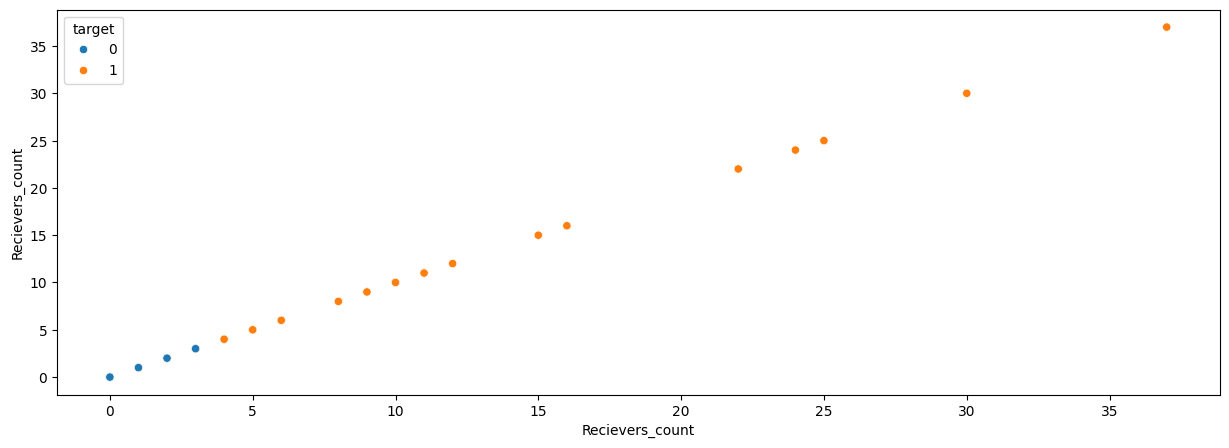

In [24]:
plt.figure(figsize=(15,5))
sns.scatterplot(x=spam_data['Recievers_count'],y=spam_data['Recievers_count'], hue=spam_data['target'])
plt.show()

<h4><font face=verdona><b> Observation : </b><br>Again the graph above validates my knowledge, as emails with higher recievers count are marked as spam.

<h4><font color=yellow face=verdona><hr>Analyzing "Date" feature<hr></font>

In [25]:
len(spam_data['Date'].unique())

5251

In [26]:
spam_data['Date']

0                        sat, 27 jul 2002 14:27:49 +0100 
1                        tue, 04 jun 2002 00:18:34 -1600 
2                        fri, 26 jul 0102 18:03:12 +0900 
3                         wed, 5 jun 2002 21:17:22 -0700 
4                        sat, 17 aug 2002 22:07:11 +0100 
                              ...                        
5324                     mon, 22 jul 2002 15:18:06 +0100 
5325    mon, 7 oct 2002 14:20:33 -0500 (cdt) it was a ...
5326                       sun, 21 jul 2002 16:46:01 edt 
5327    thu, 12 sep 2002 09:06:53 -0700 (pdt) on tue, ...
5328    2002-09-30t03:04:57+01:00 *internet news:* can...
Name: Date, Length: 5329, dtype: object

<h4><font face=verdona>Date format is consistent but it seems to have text as well which maybe part of the body of the email thus extracting the trailing text

In [27]:
date_format_len = len('Sat, 27 Jul 2002 14:27:49 +0100')
def extract_date_content(date, date_format_len=date_format_len):
    if pd.isna(date):
        return np.nan
    else : 
        date_content = date[date_format_len:]
        if "t)" in date_content:
            date_content =  date_content.split("t)")[-1]
        return date_content
    

spam_data['Date_content'] = spam_data['Date'].apply(extract_date_content)
spam_data['Date_content'].value_counts()

Date_content
                                                                                                                                                                                                                                                                                                                                                                               2049
                                                                                                                                                                                                                                                                                                                                                                                705
 >                                                                                                                                                                                                                                                 

In [28]:
def clean_text(text):
    if pd.isna(text):
        return np.nan
    else :
        # Replaces URLs in a string with a single space.
        url_pattern = re.compile(r'https?://\S+|www\.\S+|\b\S+\.(?:com|org|net|gov|edu|io|co|in|info)\b')
        no_links_text = url_pattern.sub(' ', text)

        # Removes all punctuations, numbers and symbols
        words = [word for word in no_links_text.split() if not ( '>' in word or '<' in word or '=' in word)]
        no_tags_text = ' '.join(words)
        cleaned_text = re.sub(r'[^a-zA-Z\s]', ' ', no_tags_text)
        if cleaned_text.strip() != '':
            return extra_space_remover(cleaned_text)
        else :
            return np.nan
    
spam_data['Date_content'] = spam_data['Date_content'].apply(clean_text)
spam_data['Date_content'].value_counts()

Date_content
original message                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       29
begin pgp signed message                                                                                                                                                                                                                                         

In [29]:
spam_data.isna().sum()

text                            0
target                          0
Date                            0
Subject                         7
Re                           3136
Received                      133
Content-type                  739
Precedence                   2248
Content-transfer-encoding    2692
List-unsubscribe             2982
List-subscribe               3093
In-reply-to                  3690
Wrote                        4215
Recievers_count                 0
Date_content                 2867
dtype: int64

In [30]:
spam_data.drop(columns=['Date'], inplace=True)
spam_data

,text,target,Subject,Re,Received,Content-type,Precedence,Content-transfer-encoding,List-unsubscribe,List-subscribe,In-reply-to,Wrote,Recievers_count,Date_content
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,0,,[ilug] architecture crossover trouble w rh7.2 ...,(from cdaly@localhost) by hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,bulk,None,None,None,<0d443c91dce9cd40b1c795ba222a729e018854fa@mile...,None,0,NaN
1,from gort44@excite.com mon jun 24 17:54:21 200...,1,cash in on your home equity,None,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""windows-1252""",None,7bit mortgage lenders & brokers are ready to c...,None,None,None,None,0,NaN
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,1,are your mortgage rates the best they can be.....,None,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""",bulk,"8bit dear homeowner, interest rates are at the...",",",",",None,None,0,NaN
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,1,online approval for $5000 now,None,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,None,"7bit free card search sincerely,your new offer...",None,None,None,None,1,NaN
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,0,,[ilug] expanding a string multiple times,"by prodigy.redbrick.dcu.ie (postfix, from user...",text/plain; charset=us-ascii,bulk,None,None,None,<20020817100644.ga29167@chewie.compsoc.com>; f...,None,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,0,[ilug] nmap results > i had posted previously ...,[ilug] nmap results,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",bulk,7bit,None,None,None,None,0,NaN
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,0,,the absurdities of life.,from localhost (sendmail-bs@127.0.0.1) by loca...,text/plain; charset=us-ascii,bulk,None,",",",",<3283394680.20021007145936@magnesium.net>,> > > so i get a check from pac bell today (sb...,1,it was a kick when an apt manager kept mailing...
5326,received: from hq.pro-ns.net (localhost [127.0...,1,real drugs-viagra and phentrimine!,None,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",bulk,None,None,None,None,None,1,NaN
5327,from razor-users-admin@lists.sourceforge.net t...,0,home based business for grownups sep 12 12:04:...,None,from localhost (drais@localhost) by wow.atlast...,text/plain; charset=us-ascii,bulk,None,",",",",,> use the sample-spam.txt from spamassassin an...,0,on tue sep rose bobby


<h4><font color=yellow face=verdona><hr>Analyzing "Subject" and "Re" feature<hr></font>

<h4><font face=verdona>"Re:" is part of an email header—specifically, it appears in the subject line to indicate a reply to a previous message.

In [31]:
spam_data['Subject'] = np.where(spam_data['Subject'].str.strip() == '', np.nan, spam_data['Subject'])
spam_data['Subject'].isna().sum()

np.int64(2133)

In [32]:
spam_data['Re'] = np.where(spam_data['Re'].str.strip() == '', np.nan, spam_data['Re'])
spam_data['Re'].isna().sum()

np.int64(3146)

In [33]:
spam_data['Subject'] = spam_data['Subject'].fillna('')
spam_data['Re'] = spam_data['Re'].fillna('')

In [34]:
print(f'Null Records : \nSubject :', spam_data['Subject'].isna().sum(), '\nRe : ', spam_data['Re'].isna().sum())

Null Records : 
Subject : 0 
Re :  0


In [35]:
spam_data['Subject'] = spam_data['Subject'].astype(str) + spam_data['Re'].astype(str)
spam_data

,text,target,Subject,Re,Received,Content-type,Precedence,Content-transfer-encoding,List-unsubscribe,List-subscribe,In-reply-to,Wrote,Recievers_count,Date_content
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,0,[ilug] architecture crossover trouble w rh7.2 ...,[ilug] architecture crossover trouble w rh7.2 ...,(from cdaly@localhost) by hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,bulk,None,None,None,<0d443c91dce9cd40b1c795ba222a729e018854fa@mile...,None,0,NaN
1,from gort44@excite.com mon jun 24 17:54:21 200...,1,cash in on your home equity,,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""windows-1252""",None,7bit mortgage lenders & brokers are ready to c...,None,None,None,None,0,NaN
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,1,are your mortgage rates the best they can be.....,,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""",bulk,"8bit dear homeowner, interest rates are at the...",",",",",None,None,0,NaN
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,1,online approval for $5000 now,,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,None,"7bit free card search sincerely,your new offer...",None,None,None,None,1,NaN
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,0,[ilug] expanding a string multiple times,[ilug] expanding a string multiple times,"by prodigy.redbrick.dcu.ie (postfix, from user...",text/plain; charset=us-ascii,bulk,None,None,None,<20020817100644.ga29167@chewie.compsoc.com>; f...,None,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,0,[ilug] nmap results > i had posted previously ...,[ilug] nmap results,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",bulk,7bit,None,None,None,None,0,NaN
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,0,the absurdities of life.,the absurdities of life.,from localhost (sendmail-bs@127.0.0.1) by loca...,text/plain; charset=us-ascii,bulk,None,",",",",<3283394680.20021007145936@magnesium.net>,> > > so i get a check from pac bell today (sb...,1,it was a kick when an apt manager kept mailing...
5326,received: from hq.pro-ns.net (localhost [127.0...,1,real drugs-viagra and phentrimine!,,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",bulk,None,None,None,None,None,1,NaN
5327,from razor-users-admin@lists.sourceforge.net t...,0,home based business for grownups sep 12 12:04:...,,from localhost (drais@localhost) by wow.atlast...,text/plain; charset=us-ascii,bulk,None,",",",",,> use the sample-spam.txt from spamassassin an...,0,on tue sep rose bobby


In [36]:
spam_data.drop(columns=['Re'], inplace=True)
spam_data['Subject'] = np.where(spam_data['Subject'].str.strip() == '', np.nan, spam_data['Subject'])
spam_data

,text,target,Subject,Received,Content-type,Precedence,Content-transfer-encoding,List-unsubscribe,List-subscribe,In-reply-to,Wrote,Recievers_count,Date_content
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,0,[ilug] architecture crossover trouble w rh7.2 ...,(from cdaly@localhost) by hobbiton.cod.ie (8.1...,text/plain; charset=us-ascii,bulk,None,None,None,<0d443c91dce9cd40b1c795ba222a729e018854fa@mile...,None,0,NaN
1,from gort44@excite.com mon jun 24 17:54:21 200...,1,cash in on your home equity,from 216.77.61.89 (unverified [218.5.180.148])...,"text/plain; charset=""windows-1252""",None,7bit mortgage lenders & brokers are ready to c...,None,None,None,None,0,NaN
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,1,are your mortgage rates the best they can be.....,from 46.67.186.19 ([46.67.186.19]) by q4.quick...,"text/plain; charset=""us-ascii""",bulk,"8bit dear homeowner, interest rates are at the...",",",",",None,None,0,NaN
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,1,online approval for $5000 now,from smtp0115.mail.yahoo.com (dsl-200-67-46-59...,text/html; charset=us-ascii,None,"7bit free card search sincerely,your new offer...",None,None,None,None,1,NaN
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,0,[ilug] expanding a string multiple times,"by prodigy.redbrick.dcu.ie (postfix, from user...",text/plain; charset=us-ascii,bulk,None,None,None,<20020817100644.ga29167@chewie.compsoc.com>; f...,None,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,0,[ilug] nmap results > i had posted previously ...,from xeljreilly (xeljreilly.talbot.xelector.co...,"text/plain; charset=""iso-8859-1""",bulk,7bit,None,None,None,None,0,NaN
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,0,the absurdities of life.,from localhost (sendmail-bs@127.0.0.1) by loca...,text/plain; charset=us-ascii,bulk,None,",",",",<3283394680.20021007145936@magnesium.net>,> > > so i get a check from pac bell today (sb...,1,it was a kick when an apt manager kept mailing...
5326,received: from hq.pro-ns.net (localhost [127.0...,1,real drugs-viagra and phentrimine!,(from pmguser@localhost) by s1089.mb00.net (8....,"text/html; charset=""iso-8859-1""",bulk,None,None,None,None,None,1,NaN
5327,from razor-users-admin@lists.sourceforge.net t...,0,home based business for grownups sep 12 12:04:...,from localhost (drais@localhost) by wow.atlast...,text/plain; charset=us-ascii,bulk,None,",",",",,> use the sample-spam.txt from spamassassin an...,0,on tue sep rose bobby


In [37]:
print(f'Null Records : \nSubject :', spam_data['Subject'].isna().sum())

Null Records : 
Subject : 159


<h4><font color=yellow face=verdona><hr>Analyzing "Recieved:" feature<hr>

<h4><font face=verdona>"Recieved from" ip addresses of the emails are not a reliable feature to predict if the mail is spam or legit.

In [38]:
spam_data['Received'].value_counts()

Received
from localhost (localhost [[                                                                                                                                                                                                 10
from myrealbox.com danielpavel@smtp-send.myrealbox.com [194.102.210.216] by smtp-send.myrealbox.com with netmail smtp agent $                                                                                                 3
from smtp0412.mail.yahoo.com (monedaxpress [12.96.193.210]) by ntserver.domain with smtp (microsoft exchange internet mail service version 5.5.2653.13) id pg5qzv08; tue, 23 jul 2002 16:34:15 +0100                          3
from 202 (indecp.lnk.telstra.net [139.130.38.75]) by indec-ntserver.indec.com.au with smtp (microsoft exchange internet mail service version 5.5.2650.21) id 35kjcma9; sat, 28 jul 2001 17:45:55 +1000                        3
from 211.97.147.11 ([211.97.147.11]) by info.chinacoal.gov.cn with smtp (microsoft exchange int

In [39]:
spam_data.drop(columns=['Received'], inplace=True)
spam_data

,text,target,Subject,Content-type,Precedence,Content-transfer-encoding,List-unsubscribe,List-subscribe,In-reply-to,Wrote,Recievers_count,Date_content
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,0,[ilug] architecture crossover trouble w rh7.2 ...,text/plain; charset=us-ascii,bulk,None,None,None,<0d443c91dce9cd40b1c795ba222a729e018854fa@mile...,None,0,NaN
1,from gort44@excite.com mon jun 24 17:54:21 200...,1,cash in on your home equity,"text/plain; charset=""windows-1252""",None,7bit mortgage lenders & brokers are ready to c...,None,None,None,None,0,NaN
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,1,are your mortgage rates the best they can be.....,"text/plain; charset=""us-ascii""",bulk,"8bit dear homeowner, interest rates are at the...",",",",",None,None,0,NaN
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,1,online approval for $5000 now,text/html; charset=us-ascii,None,"7bit free card search sincerely,your new offer...",None,None,None,None,1,NaN
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,0,[ilug] expanding a string multiple times,text/plain; charset=us-ascii,bulk,None,None,None,<20020817100644.ga29167@chewie.compsoc.com>; f...,None,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,0,[ilug] nmap results > i had posted previously ...,"text/plain; charset=""iso-8859-1""",bulk,7bit,None,None,None,None,0,NaN
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,0,the absurdities of life.,text/plain; charset=us-ascii,bulk,None,",",",",<3283394680.20021007145936@magnesium.net>,> > > so i get a check from pac bell today (sb...,1,it was a kick when an apt manager kept mailing...
5326,received: from hq.pro-ns.net (localhost [127.0...,1,real drugs-viagra and phentrimine!,"text/html; charset=""iso-8859-1""",bulk,None,None,None,None,None,1,NaN
5327,from razor-users-admin@lists.sourceforge.net t...,0,home based business for grownups sep 12 12:04:...,text/plain; charset=us-ascii,bulk,None,",",",",,> use the sample-spam.txt from spamassassin an...,0,on tue sep rose bobby


<h4><font color=yellow face=verdona><hr>Analyzing "Content-Type:" feature<hr>

In [40]:
spam_data['Content-type'].isna().sum()

np.int64(739)

In [41]:
spam_data['Content-type'].value_counts()

Content-type
text/plain; charset=us-ascii                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [42]:
def extract_content_type_content(input_value):
    if pd.isna(input_value):
        return np.nan
    elif '"' in input_value :
        parts = input_value.split('"')
        if len(parts) > 1 :
            if ((parts[-1].strip() != '') and  (';' not in parts[-1].strip())):
                return parts[-1].strip()
            else :
                return np.nan
        else : 
            return np.nan
    else :
        return np.nan

spam_data['Content-type-content'] = spam_data['Content-type'].apply(extract_content_type_content)
spam_data['Content-type-content'] = spam_data['Content-type-content'].apply(clean_text)
spam_data['Content-type-content'].value_counts()

Content-type-content
maybe you think it s impossible to get free money let me tell you it s not impossible it s a fact ordinary people and businesses all across the united states are receiving millions of dollars from these government and private foundation s everyday who can apply anyone can apply for a grant from years old and up grants from to are possible grants don t have to be paid back ever claim your slice of the free american pie this money is not a loan trying to get money through a conventional bank can be very time consuming and requires a lot of paperwork only to find out that you ve been denied these government agencies don t have to operate under the same stringent requirements that banks do you decide how much money you need as long as it s a lawful amount and meets with the government agencies criteria the money is yours to keep and never has to be repaid this money is non taxable interest free none of these programs require a credit check collateral security deposits 

In [43]:
def extract_cont_type(text):
    if pd.isna(text):
        return "none"
    elif 'html' in text :
        return 'html'
    elif 'plain' in text :
        return 'plain'
    else :
        return "none"
    


spam_data['Content-type'] = spam_data['Content-type'].apply(extract_cont_type)
spam_data['Content-type'].value_counts()

Content-type
plain    3520
html      937
none      872
Name: count, dtype: int64

<h4><font face=verdona>We know formal/ non advertising emails contain plain text whereas adverstising or spam emails contain html type text

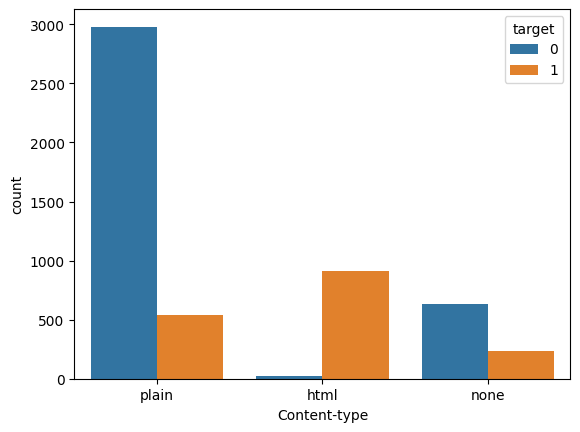

In [44]:
sns.countplot(x=spam_data['Content-type'], hue=spam_data['target'])
plt.show()

<h4><font face=verdona><b> Observation : </b><br>The graph above validates my knowledge, thus we will use one hot encoding to use this feature in our dataframe. Each category is associated with a class of the independent variable.

<h4><font color=yellow face=verdona><hr>Analyzing "Precedence" feature<hr></font

In [45]:
spam_data['Precedence'].value_counts()

Precedence
bulk                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

<h4><font face=verdona>We can see the most number of records are either null or "bulk",  but there are  few records, that contain any content so we need to parse the content and extract it

In [46]:
def extract_prec_content(input_value):
    if pd.isna(input_value):
        return np.nan
    elif input_value[5:].strip() != '' :
        return input_value[5:].strip()
    else :
        return np.nan
    
spam_data['Prec_content'] = spam_data['Precedence'].apply(extract_prec_content)
spam_data['Prec_content'] = spam_data['Prec_content'].apply(clean_text)
spam_data

,text,target,Subject,Content-type,Precedence,Content-transfer-encoding,List-unsubscribe,List-subscribe,In-reply-to,Wrote,Recievers_count,Date_content,Content-type-content,Prec_content
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,0,[ilug] architecture crossover trouble w rh7.2 ...,plain,bulk,None,None,None,<0d443c91dce9cd40b1c795ba222a729e018854fa@mile...,None,0,NaN,NaN,NaN
1,from gort44@excite.com mon jun 24 17:54:21 200...,1,cash in on your home equity,plain,None,7bit mortgage lenders & brokers are ready to c...,None,None,None,None,0,NaN,NaN,NaN
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,1,are your mortgage rates the best they can be.....,plain,bulk,"8bit dear homeowner, interest rates are at the...",",",",",None,None,0,NaN,NaN,NaN
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,1,online approval for $5000 now,html,None,"7bit free card search sincerely,your new offer...",None,None,None,None,1,NaN,NaN,NaN
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,0,[ilug] expanding a string multiple times,plain,bulk,None,None,None,<20020817100644.ga29167@chewie.compsoc.com>; f...,None,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,0,[ilug] nmap results > i had posted previously ...,plain,bulk,7bit,None,None,None,None,0,NaN,NaN,NaN
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,0,the absurdities of life.,plain,bulk,None,",",",",<3283394680.20021007145936@magnesium.net>,> > > so i get a check from pac bell today (sb...,1,it was a kick when an apt manager kept mailing...,NaN,NaN
5326,received: from hq.pro-ns.net (localhost [127.0...,1,real drugs-viagra and phentrimine!,html,bulk,None,None,None,None,None,1,NaN,NaN,NaN
5327,from razor-users-admin@lists.sourceforge.net t...,0,home based business for grownups sep 12 12:04:...,plain,bulk,None,",",",",,> use the sample-spam.txt from spamassassin an...,0,on tue sep rose bobby,NaN,NaN


In [47]:
spam_data['Prec_content'].value_counts()

Prec_content
class                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [48]:
def clean_precendence(input_value):
    if pd.isna(input_value):
        return np.nan
    elif input_value.strip() != '' :
        return input_value[:5].strip()
    else :
        return np.nan

spam_data['Precedence'] = spam_data['Precedence'].apply(clean_precendence)
spam_data

,text,target,Subject,Content-type,Precedence,Content-transfer-encoding,List-unsubscribe,List-subscribe,In-reply-to,Wrote,Recievers_count,Date_content,Content-type-content,Prec_content
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,0,[ilug] architecture crossover trouble w rh7.2 ...,plain,bulk,None,None,None,<0d443c91dce9cd40b1c795ba222a729e018854fa@mile...,None,0,NaN,NaN,NaN
1,from gort44@excite.com mon jun 24 17:54:21 200...,1,cash in on your home equity,plain,NaN,7bit mortgage lenders & brokers are ready to c...,None,None,None,None,0,NaN,NaN,NaN
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,1,are your mortgage rates the best they can be.....,plain,bulk,"8bit dear homeowner, interest rates are at the...",",",",",None,None,0,NaN,NaN,NaN
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,1,online approval for $5000 now,html,NaN,"7bit free card search sincerely,your new offer...",None,None,None,None,1,NaN,NaN,NaN
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,0,[ilug] expanding a string multiple times,plain,bulk,None,None,None,<20020817100644.ga29167@chewie.compsoc.com>; f...,None,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,0,[ilug] nmap results > i had posted previously ...,plain,bulk,7bit,None,None,None,None,0,NaN,NaN,NaN
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,0,the absurdities of life.,plain,bulk,None,",",",",<3283394680.20021007145936@magnesium.net>,> > > so i get a check from pac bell today (sb...,1,it was a kick when an apt manager kept mailing...,NaN,NaN
5326,received: from hq.pro-ns.net (localhost [127.0...,1,real drugs-viagra and phentrimine!,html,bulk,None,None,None,None,None,1,NaN,NaN,NaN
5327,from razor-users-admin@lists.sourceforge.net t...,0,home based business for grownups sep 12 12:04:...,plain,bulk,None,",",",",,> use the sample-spam.txt from spamassassin an...,0,on tue sep rose bobby,NaN,NaN


In [49]:
spam_data['Precedence'].value_counts()

Precedence
bulk     2976
list      101
junk        2
first       1
{bulk       1
Name: count, dtype: int64

In [50]:
def clean_prec_text(text):
    if pd.isna(text):
        return "blank"
    else :
        cleaned_text = re.sub(r'[^a-zA-Z\s]', '', text)
        return cleaned_text

spam_data['Precedence'] = spam_data['Precedence'].apply(clean_prec_text)
spam_data['Precedence'].value_counts()

Precedence
bulk     2977
blank    2248
list      101
junk        2
first       1
Name: count, dtype: int64

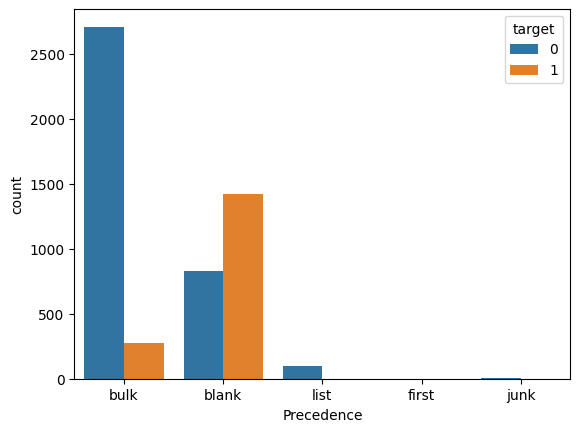

In [51]:
sns.countplot(x=spam_data['Precedence'], hue=spam_data['target'])
plt.show()

In [52]:
spam_data['Precedence'] = np.where(spam_data['Precedence'] != "blank", "bulk", spam_data['Precedence'])
spam_data['Precedence'].value_counts()

Precedence
bulk     3081
blank    2248
Name: count, dtype: int64

<h4><font face=verdona>Encoding Precedence feature

In [53]:
spam_data['Precedence'] = spam_data['Precedence'].map({'bulk':0, 'blank':1})
spam_data['Precedence'].value_counts()

Precedence
0    3081
1    2248
Name: count, dtype: int64

<h4><font color=yellow face=verdona><hr>Analyzing "Content-transfer-encoding" feature<hr></font>

In [54]:
spam_data['Content-transfer-encoding'].value_counts()

Content-transfer-encoding
7bit                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

<h4><font face=verdona>Removing punctuation, special characters and numbers and extra spaces,newlines, tab spaces

In [55]:
def clean_cte(text):
    if pd.isna(text):
        return np.nan
    elif 'bit' in text:
        extracted_text = text.strip()[4:]
        cleaned_text = clean_text(extracted_text)
    elif 'quoted-printable' in text:
        extracted_text = text.strip()[len('quoted-printable'):]
        cleaned_text = clean_text(extracted_text)
    else :
        cleaned_text = clean_text(text)
    if cleaned_text != '':
        return cleaned_text
    else :
        return np.nan
    

spam_data['Content-transfer-encoding'] = spam_data['Content-transfer-encoding'].apply(clean_cte)
spam_data['Content-transfer-encoding'].value_counts()

Content-transfer-encoding
base                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [56]:
spam_data

,text,target,Subject,Content-type,Precedence,Content-transfer-encoding,List-unsubscribe,List-subscribe,In-reply-to,Wrote,Recievers_count,Date_content,Content-type-content,Prec_content
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,0,[ilug] architecture crossover trouble w rh7.2 ...,plain,0,NaN,None,None,<0d443c91dce9cd40b1c795ba222a729e018854fa@mile...,None,0,NaN,NaN,NaN
1,from gort44@excite.com mon jun 24 17:54:21 200...,1,cash in on your home equity,plain,1,mortgage lenders brokers are ready to compete ...,None,None,None,None,0,NaN,NaN,NaN
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,1,are your mortgage rates the best they can be.....,plain,0,dear homeowner interest rates are at their low...,",",",",None,None,0,NaN,NaN,NaN
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,1,online approval for $5000 now,html,1,free card search sincerely your new offers sta...,None,None,None,None,1,NaN,NaN,NaN
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,0,[ilug] expanding a string multiple times,plain,0,NaN,None,None,<20020817100644.ga29167@chewie.compsoc.com>; f...,None,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,0,[ilug] nmap results > i had posted previously ...,plain,0,NaN,None,None,None,None,0,NaN,NaN,NaN
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,0,the absurdities of life.,plain,0,NaN,",",",",<3283394680.20021007145936@magnesium.net>,> > > so i get a check from pac bell today (sb...,1,it was a kick when an apt manager kept mailing...,NaN,NaN
5326,received: from hq.pro-ns.net (localhost [127.0...,1,real drugs-viagra and phentrimine!,html,0,NaN,None,None,None,None,1,NaN,NaN,NaN
5327,from razor-users-admin@lists.sourceforge.net t...,0,home based business for grownups sep 12 12:04:...,plain,0,NaN,",",",",,> use the sample-spam.txt from spamassassin an...,0,on tue sep rose bobby,NaN,NaN


<h4><font color=yellow face=verdona><hr>Analyzing "List-subscribe,List-unsubscribe" feature<hr></font>
<h4><font face=verdona> "list-subscribe" indicates the recipient has enrolled for email communications, while "list-unsubscribe" provides a mechanism for them to opt-out and stop receiving emails from that specific mailing list or organization - Google<br>Therefore, emails containing a subscribe link suggest that the recipient willingly signed up to receive them, making them less likely to be spam. The same applies to emails with an unsubscribe option, as legitimate senders typically include it to comply with email regulations.

In [57]:
spam_data['target'] = spam_data['target'].map({0: 'not_spam', 1: 'spam'})

In [58]:
spam_data['List-subscribe'] = np.where(pd.isna(spam_data['List-subscribe']), "Not_subscribed", "Subscribed")
spam_data['List-unsubscribe'] = np.where(pd.isna(spam_data['List-unsubscribe']), "No_unsub_option", "unsub_option")
spam_data

,text,target,Subject,Content-type,Precedence,Content-transfer-encoding,List-unsubscribe,List-subscribe,In-reply-to,Wrote,Recievers_count,Date_content,Content-type-content,Prec_content
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,not_spam,[ilug] architecture crossover trouble w rh7.2 ...,plain,0,NaN,No_unsub_option,Not_subscribed,<0d443c91dce9cd40b1c795ba222a729e018854fa@mile...,None,0,NaN,NaN,NaN
1,from gort44@excite.com mon jun 24 17:54:21 200...,spam,cash in on your home equity,plain,1,mortgage lenders brokers are ready to compete ...,No_unsub_option,Not_subscribed,None,None,0,NaN,NaN,NaN
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,spam,are your mortgage rates the best they can be.....,plain,0,dear homeowner interest rates are at their low...,unsub_option,Subscribed,None,None,0,NaN,NaN,NaN
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,spam,online approval for $5000 now,html,1,free card search sincerely your new offers sta...,No_unsub_option,Not_subscribed,None,None,1,NaN,NaN,NaN
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,not_spam,[ilug] expanding a string multiple times,plain,0,NaN,No_unsub_option,Not_subscribed,<20020817100644.ga29167@chewie.compsoc.com>; f...,None,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,not_spam,[ilug] nmap results > i had posted previously ...,plain,0,NaN,No_unsub_option,Not_subscribed,None,None,0,NaN,NaN,NaN
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,not_spam,the absurdities of life.,plain,0,NaN,unsub_option,Subscribed,<3283394680.20021007145936@magnesium.net>,> > > so i get a check from pac bell today (sb...,1,it was a kick when an apt manager kept mailing...,NaN,NaN
5326,received: from hq.pro-ns.net (localhost [127.0...,spam,real drugs-viagra and phentrimine!,html,0,NaN,No_unsub_option,Not_subscribed,None,None,1,NaN,NaN,NaN
5327,from razor-users-admin@lists.sourceforge.net t...,not_spam,home based business for grownups sep 12 12:04:...,plain,0,NaN,unsub_option,Subscribed,,> use the sample-spam.txt from spamassassin an...,0,on tue sep rose bobby,NaN,NaN


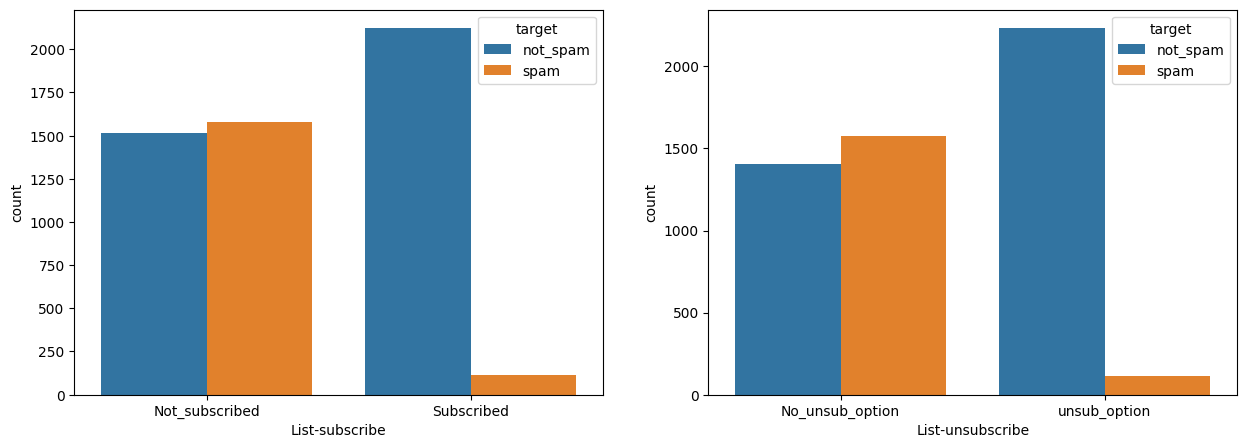

In [59]:
fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.countplot(x=spam_data['List-subscribe'], hue=spam_data['target'], ax=ax[0])
sns.countplot(x=spam_data['List-unsubscribe'], hue=spam_data['target'], ax=ax[1])
plt.show()

<h4><font face=verdona><b> Observation : </b><br>The graph above validates my knowledge, as emails with Subscription,Unsubscribe option present are mostly marked as not spam.

In [60]:
spam_data['Sub_Unsub_link'] = np.where(
    (spam_data['List-subscribe'] == 'Subscribed') | (spam_data['List-unsubscribe'] == 'unsub_option'), 1, 0)
spam_data

,text,target,Subject,Content-type,Precedence,Content-transfer-encoding,List-unsubscribe,List-subscribe,In-reply-to,Wrote,Recievers_count,Date_content,Content-type-content,Prec_content,Sub_Unsub_link
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,not_spam,[ilug] architecture crossover trouble w rh7.2 ...,plain,0,NaN,No_unsub_option,Not_subscribed,<0d443c91dce9cd40b1c795ba222a729e018854fa@mile...,None,0,NaN,NaN,NaN,0
1,from gort44@excite.com mon jun 24 17:54:21 200...,spam,cash in on your home equity,plain,1,mortgage lenders brokers are ready to compete ...,No_unsub_option,Not_subscribed,None,None,0,NaN,NaN,NaN,0
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,spam,are your mortgage rates the best they can be.....,plain,0,dear homeowner interest rates are at their low...,unsub_option,Subscribed,None,None,0,NaN,NaN,NaN,1
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,spam,online approval for $5000 now,html,1,free card search sincerely your new offers sta...,No_unsub_option,Not_subscribed,None,None,1,NaN,NaN,NaN,0
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,not_spam,[ilug] expanding a string multiple times,plain,0,NaN,No_unsub_option,Not_subscribed,<20020817100644.ga29167@chewie.compsoc.com>; f...,None,1,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,not_spam,[ilug] nmap results > i had posted previously ...,plain,0,NaN,No_unsub_option,Not_subscribed,None,None,0,NaN,NaN,NaN,0
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,not_spam,the absurdities of life.,plain,0,NaN,unsub_option,Subscribed,<3283394680.20021007145936@magnesium.net>,> > > so i get a check from pac bell today (sb...,1,it was a kick when an apt manager kept mailing...,NaN,NaN,1
5326,received: from hq.pro-ns.net (localhost [127.0...,spam,real drugs-viagra and phentrimine!,html,0,NaN,No_unsub_option,Not_subscribed,None,None,1,NaN,NaN,NaN,0
5327,from razor-users-admin@lists.sourceforge.net t...,not_spam,home based business for grownups sep 12 12:04:...,plain,0,NaN,unsub_option,Subscribed,,> use the sample-spam.txt from spamassassin an...,0,on tue sep rose bobby,NaN,NaN,1


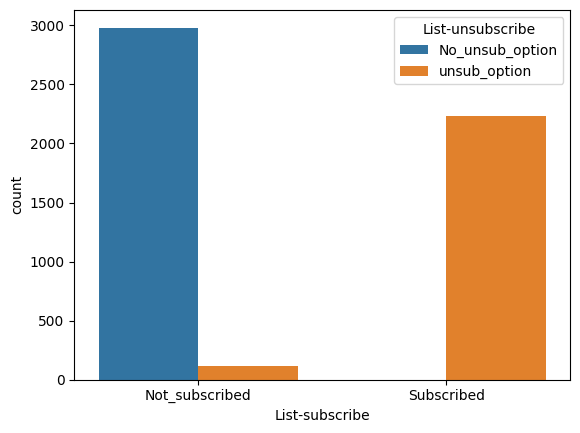

In [61]:
sns.countplot(x=spam_data['List-subscribe'], hue=spam_data['List-unsubscribe'])
plt.show()

<h4><font face=verdona>We know the emails that have subscription will only have the unsubsription option, as also can be seen in the above graph.

In [62]:
spam_data.drop(columns=['List-subscribe','List-unsubscribe'], inplace=True)
spam_data

,text,target,Subject,Content-type,Precedence,Content-transfer-encoding,In-reply-to,Wrote,Recievers_count,Date_content,Content-type-content,Prec_content,Sub_Unsub_link
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,not_spam,[ilug] architecture crossover trouble w rh7.2 ...,plain,0,NaN,<0d443c91dce9cd40b1c795ba222a729e018854fa@mile...,None,0,NaN,NaN,NaN,0
1,from gort44@excite.com mon jun 24 17:54:21 200...,spam,cash in on your home equity,plain,1,mortgage lenders brokers are ready to compete ...,None,None,0,NaN,NaN,NaN,0
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,spam,are your mortgage rates the best they can be.....,plain,0,dear homeowner interest rates are at their low...,None,None,0,NaN,NaN,NaN,1
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,spam,online approval for $5000 now,html,1,free card search sincerely your new offers sta...,None,None,1,NaN,NaN,NaN,0
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,not_spam,[ilug] expanding a string multiple times,plain,0,NaN,<20020817100644.ga29167@chewie.compsoc.com>; f...,None,1,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,not_spam,[ilug] nmap results > i had posted previously ...,plain,0,NaN,None,None,0,NaN,NaN,NaN,0
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,not_spam,the absurdities of life.,plain,0,NaN,<3283394680.20021007145936@magnesium.net>,> > > so i get a check from pac bell today (sb...,1,it was a kick when an apt manager kept mailing...,NaN,NaN,1
5326,received: from hq.pro-ns.net (localhost [127.0...,spam,real drugs-viagra and phentrimine!,html,0,NaN,None,None,1,NaN,NaN,NaN,0
5327,from razor-users-admin@lists.sourceforge.net t...,not_spam,home based business for grownups sep 12 12:04:...,plain,0,NaN,,> use the sample-spam.txt from spamassassin an...,0,on tue sep rose bobby,NaN,NaN,1


<h4><font color=yellow face=verdona><hr>Analyzing "In-reply-to" feature<hr></font>
<h4><font face=verdona>We know a replied email will never be classified as spam; only emails that are not replies can be marked as spam.

In [63]:
spam_data['Replied_mail'] = np.where(pd.isna(spam_data['In-reply-to']), 0, 1)
spam_data

,text,target,Subject,Content-type,Precedence,Content-transfer-encoding,In-reply-to,Wrote,Recievers_count,Date_content,Content-type-content,Prec_content,Sub_Unsub_link,Replied_mail
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,not_spam,[ilug] architecture crossover trouble w rh7.2 ...,plain,0,NaN,<0d443c91dce9cd40b1c795ba222a729e018854fa@mile...,None,0,NaN,NaN,NaN,0,1
1,from gort44@excite.com mon jun 24 17:54:21 200...,spam,cash in on your home equity,plain,1,mortgage lenders brokers are ready to compete ...,None,None,0,NaN,NaN,NaN,0,0
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,spam,are your mortgage rates the best they can be.....,plain,0,dear homeowner interest rates are at their low...,None,None,0,NaN,NaN,NaN,1,0
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,spam,online approval for $5000 now,html,1,free card search sincerely your new offers sta...,None,None,1,NaN,NaN,NaN,0,0
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,not_spam,[ilug] expanding a string multiple times,plain,0,NaN,<20020817100644.ga29167@chewie.compsoc.com>; f...,None,1,NaN,NaN,NaN,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,not_spam,[ilug] nmap results > i had posted previously ...,plain,0,NaN,None,None,0,NaN,NaN,NaN,0,0
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,not_spam,the absurdities of life.,plain,0,NaN,<3283394680.20021007145936@magnesium.net>,> > > so i get a check from pac bell today (sb...,1,it was a kick when an apt manager kept mailing...,NaN,NaN,1,1
5326,received: from hq.pro-ns.net (localhost [127.0...,spam,real drugs-viagra and phentrimine!,html,0,NaN,None,None,1,NaN,NaN,NaN,0,0
5327,from razor-users-admin@lists.sourceforge.net t...,not_spam,home based business for grownups sep 12 12:04:...,plain,0,NaN,,> use the sample-spam.txt from spamassassin an...,0,on tue sep rose bobby,NaN,NaN,1,1


In [64]:
spam_data.isna().sum()

text                            0
target                          0
Subject                       159
Content-type                    0
Precedence                      0
Content-transfer-encoding    4313
In-reply-to                  3690
Wrote                        4215
Recievers_count                 0
Date_content                 2867
Content-type-content         5148
Prec_content                 5320
Sub_Unsub_link                  0
Replied_mail                    0
dtype: int64

In [65]:
spam_data.drop(columns=['In-reply-to'], inplace=True)
spam_data

,text,target,Subject,Content-type,Precedence,Content-transfer-encoding,Wrote,Recievers_count,Date_content,Content-type-content,Prec_content,Sub_Unsub_link,Replied_mail
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,not_spam,[ilug] architecture crossover trouble w rh7.2 ...,plain,0,NaN,None,0,NaN,NaN,NaN,0,1
1,from gort44@excite.com mon jun 24 17:54:21 200...,spam,cash in on your home equity,plain,1,mortgage lenders brokers are ready to compete ...,None,0,NaN,NaN,NaN,0,0
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,spam,are your mortgage rates the best they can be.....,plain,0,dear homeowner interest rates are at their low...,None,0,NaN,NaN,NaN,1,0
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,spam,online approval for $5000 now,html,1,free card search sincerely your new offers sta...,None,1,NaN,NaN,NaN,0,0
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,not_spam,[ilug] expanding a string multiple times,plain,0,NaN,None,1,NaN,NaN,NaN,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,not_spam,[ilug] nmap results > i had posted previously ...,plain,0,NaN,None,0,NaN,NaN,NaN,0,0
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,not_spam,the absurdities of life.,plain,0,NaN,> > > so i get a check from pac bell today (sb...,1,it was a kick when an apt manager kept mailing...,NaN,NaN,1,1
5326,received: from hq.pro-ns.net (localhost [127.0...,spam,real drugs-viagra and phentrimine!,html,0,NaN,None,1,NaN,NaN,NaN,0,0
5327,from razor-users-admin@lists.sourceforge.net t...,not_spam,home based business for grownups sep 12 12:04:...,plain,0,NaN,> use the sample-spam.txt from spamassassin an...,0,on tue sep rose bobby,NaN,NaN,1,1


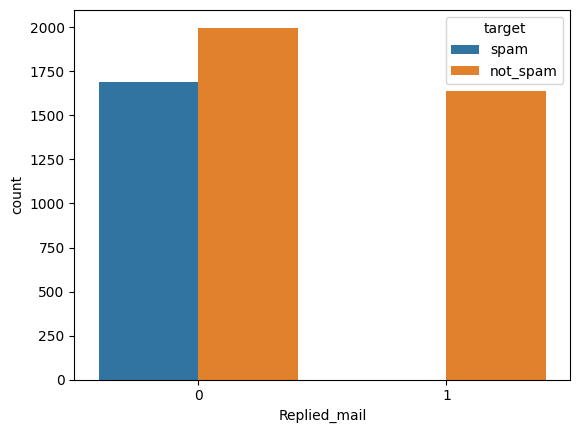

In [66]:
sns.countplot(x=spam_data['Replied_mail'], hue=spam_data['target'])
plt.show()

<h4><font face=verdona><b> Observation : </b><br>The graph above validates my knowledge, as none of the replied emails are marked as spam.

<h4><font color=yellow face=verdona><hr>Analyzing "Wrote" feature<hr></font>

In [67]:
spam_data['Wrote'].value_counts()

Wrote
>                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [68]:
spam_data['Wrote'] = spam_data['Wrote'].apply(clean_text)
spam_data

,text,target,Subject,Content-type,Precedence,Content-transfer-encoding,Wrote,Recievers_count,Date_content,Content-type-content,Prec_content,Sub_Unsub_link,Replied_mail
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,not_spam,[ilug] architecture crossover trouble w rh7.2 ...,plain,0,NaN,NaN,0,NaN,NaN,NaN,0,1
1,from gort44@excite.com mon jun 24 17:54:21 200...,spam,cash in on your home equity,plain,1,mortgage lenders brokers are ready to compete ...,NaN,0,NaN,NaN,NaN,0,0
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,spam,are your mortgage rates the best they can be.....,plain,0,dear homeowner interest rates are at their low...,NaN,0,NaN,NaN,NaN,1,0
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,spam,online approval for $5000 now,html,1,free card search sincerely your new offers sta...,NaN,1,NaN,NaN,NaN,0,0
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,not_spam,[ilug] expanding a string multiple times,plain,0,NaN,NaN,1,NaN,NaN,NaN,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,not_spam,[ilug] nmap results > i had posted previously ...,plain,0,NaN,NaN,0,NaN,NaN,NaN,0,0
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,not_spam,the absurdities of life.,plain,0,NaN,so i get a check from pac bell today sbc as th...,1,it was a kick when an apt manager kept mailing...,NaN,NaN,1,1
5326,received: from hq.pro-ns.net (localhost [127.0...,spam,real drugs-viagra and phentrimine!,html,0,NaN,NaN,1,NaN,NaN,NaN,0,0
5327,from razor-users-admin@lists.sourceforge.net t...,not_spam,home based business for grownups sep 12 12:04:...,plain,0,NaN,use the sample spam txt from spamassassin and ...,0,on tue sep rose bobby,NaN,NaN,1,1


In [69]:
spam_data['Wrote'].value_counts()

Wrote
who watched lathe of heaven a e pm edt who has seen the original by original if you are referring to the old pbs version i liked that version much better much more thought provoking                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  4
the mystery of                                                                                                                           

In [70]:
spam_data

,text,target,Subject,Content-type,Precedence,Content-transfer-encoding,Wrote,Recievers_count,Date_content,Content-type-content,Prec_content,Sub_Unsub_link,Replied_mail
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,not_spam,[ilug] architecture crossover trouble w rh7.2 ...,plain,0,NaN,NaN,0,NaN,NaN,NaN,0,1
1,from gort44@excite.com mon jun 24 17:54:21 200...,spam,cash in on your home equity,plain,1,mortgage lenders brokers are ready to compete ...,NaN,0,NaN,NaN,NaN,0,0
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,spam,are your mortgage rates the best they can be.....,plain,0,dear homeowner interest rates are at their low...,NaN,0,NaN,NaN,NaN,1,0
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,spam,online approval for $5000 now,html,1,free card search sincerely your new offers sta...,NaN,1,NaN,NaN,NaN,0,0
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,not_spam,[ilug] expanding a string multiple times,plain,0,NaN,NaN,1,NaN,NaN,NaN,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,not_spam,[ilug] nmap results > i had posted previously ...,plain,0,NaN,NaN,0,NaN,NaN,NaN,0,0
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,not_spam,the absurdities of life.,plain,0,NaN,so i get a check from pac bell today sbc as th...,1,it was a kick when an apt manager kept mailing...,NaN,NaN,1,1
5326,received: from hq.pro-ns.net (localhost [127.0...,spam,real drugs-viagra and phentrimine!,html,0,NaN,NaN,1,NaN,NaN,NaN,0,0
5327,from razor-users-admin@lists.sourceforge.net t...,not_spam,home based business for grownups sep 12 12:04:...,plain,0,NaN,use the sample spam txt from spamassassin and ...,0,on tue sep rose bobby,NaN,NaN,1,1


<center><h3><font face=verdona color=yellow>Cardinal Encoding using OneHotEncoder

In [71]:
ohe = OneHotEncoder(sparse_output=False) 
encoded_content_type = ohe.fit_transform(spam_data[['Content-type']]) 
encoded_df = pd.DataFrame(encoded_content_type, columns=ohe.get_feature_names_out(['Content-type']))
encoded_df.head()

,Content-type_html,Content-type_none,Content-type_plain
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0


In [72]:
spam_data['Content_type_html'] = encoded_df['Content-type_html'].astype(int)
spam_data['Content_type_plain'] = encoded_df['Content-type_plain'].astype(int)
spam_data

,text,target,Subject,Content-type,Precedence,Content-transfer-encoding,Wrote,Recievers_count,Date_content,Content-type-content,Prec_content,Sub_Unsub_link,Replied_mail,Content_type_html,Content_type_plain
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,not_spam,[ilug] architecture crossover trouble w rh7.2 ...,plain,0,NaN,NaN,0,NaN,NaN,NaN,0,1,0,1
1,from gort44@excite.com mon jun 24 17:54:21 200...,spam,cash in on your home equity,plain,1,mortgage lenders brokers are ready to compete ...,NaN,0,NaN,NaN,NaN,0,0,0,1
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,spam,are your mortgage rates the best they can be.....,plain,0,dear homeowner interest rates are at their low...,NaN,0,NaN,NaN,NaN,1,0,0,1
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,spam,online approval for $5000 now,html,1,free card search sincerely your new offers sta...,NaN,1,NaN,NaN,NaN,0,0,1,0
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,not_spam,[ilug] expanding a string multiple times,plain,0,NaN,NaN,1,NaN,NaN,NaN,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,not_spam,[ilug] nmap results > i had posted previously ...,plain,0,NaN,NaN,0,NaN,NaN,NaN,0,0,0,1
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,not_spam,the absurdities of life.,plain,0,NaN,so i get a check from pac bell today sbc as th...,1,it was a kick when an apt manager kept mailing...,NaN,NaN,1,1,0,1
5326,received: from hq.pro-ns.net (localhost [127.0...,spam,real drugs-viagra and phentrimine!,html,0,NaN,NaN,1,NaN,NaN,NaN,0,0,1,0
5327,from razor-users-admin@lists.sourceforge.net t...,not_spam,home based business for grownups sep 12 12:04:...,plain,0,NaN,use the sample spam txt from spamassassin and ...,0,on tue sep rose bobby,NaN,NaN,1,1,0,1


In [73]:
spam_data.drop(columns=['Content-type'], inplace=True)

In [74]:
spam_data

,text,target,Subject,Precedence,Content-transfer-encoding,Wrote,Recievers_count,Date_content,Content-type-content,Prec_content,Sub_Unsub_link,Replied_mail,Content_type_html,Content_type_plain
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,not_spam,[ilug] architecture crossover trouble w rh7.2 ...,0,NaN,NaN,0,NaN,NaN,NaN,0,1,0,1
1,from gort44@excite.com mon jun 24 17:54:21 200...,spam,cash in on your home equity,1,mortgage lenders brokers are ready to compete ...,NaN,0,NaN,NaN,NaN,0,0,0,1
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,spam,are your mortgage rates the best they can be.....,0,dear homeowner interest rates are at their low...,NaN,0,NaN,NaN,NaN,1,0,0,1
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,spam,online approval for $5000 now,1,free card search sincerely your new offers sta...,NaN,1,NaN,NaN,NaN,0,0,1,0
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,not_spam,[ilug] expanding a string multiple times,0,NaN,NaN,1,NaN,NaN,NaN,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,not_spam,[ilug] nmap results > i had posted previously ...,0,NaN,NaN,0,NaN,NaN,NaN,0,0,0,1
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,not_spam,the absurdities of life.,0,NaN,so i get a check from pac bell today sbc as th...,1,it was a kick when an apt manager kept mailing...,NaN,NaN,1,1,0,1
5326,received: from hq.pro-ns.net (localhost [127.0...,spam,real drugs-viagra and phentrimine!,0,NaN,NaN,1,NaN,NaN,NaN,0,0,1,0
5327,from razor-users-admin@lists.sourceforge.net t...,not_spam,home based business for grownups sep 12 12:04:...,0,NaN,use the sample spam txt from spamassassin and ...,0,on tue sep rose bobby,NaN,NaN,1,1,0,1


<h4><font face=verdona>Concatenating all the text content and into one feature

In [75]:
spam_data.columns

Index(['text', 'target', 'Subject', 'Precedence', 'Content-transfer-encoding',
       'Wrote', 'Recievers_count', 'Date_content', 'Content-type-content',
       'Prec_content', 'Sub_Unsub_link', 'Replied_mail', 'Content_type_html',
       'Content_type_plain'],
      dtype='object')

In [76]:
spam_data['Content-transfer-encoding'] = spam_data['Content-transfer-encoding'].fillna('')
spam_data['Wrote'] = spam_data['Wrote'].fillna('')
spam_data['Date_content'] = spam_data['Date_content'].fillna('')
spam_data['Content-type-content'] = spam_data['Content-type-content'].fillna('')
spam_data['Prec_content'] = spam_data['Prec_content'].fillna('')

In [77]:
spam_data['Full_content'] = spam_data['Content-transfer-encoding'].astype(str) + " " + spam_data['Wrote'].astype(str) + " " + spam_data['Date_content'].astype(str) + " " + spam_data['Content-type-content'].astype(str) + " " + spam_data['Prec_content'].astype(str)
spam_data

,text,target,Subject,Precedence,Content-transfer-encoding,Wrote,Recievers_count,Date_content,Content-type-content,Prec_content,Sub_Unsub_link,Replied_mail,Content_type_html,Content_type_plain,Full_content
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,not_spam,[ilug] architecture crossover trouble w rh7.2 ...,0,,,0,,,,0,1,0,1,
1,from gort44@excite.com mon jun 24 17:54:21 200...,spam,cash in on your home equity,1,mortgage lenders brokers are ready to compete ...,,0,,,,0,0,0,1,mortgage lenders brokers are ready to compete ...
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,spam,are your mortgage rates the best they can be.....,0,dear homeowner interest rates are at their low...,,0,,,,1,0,0,1,dear homeowner interest rates are at their low...
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,spam,online approval for $5000 now,1,free card search sincerely your new offers sta...,,1,,,,0,0,1,0,free card search sincerely your new offers sta...
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,not_spam,[ilug] expanding a string multiple times,0,,,1,,,,0,1,0,1,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,not_spam,[ilug] nmap results > i had posted previously ...,0,,,0,,,,0,0,0,1,
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,not_spam,the absurdities of life.,0,,so i get a check from pac bell today sbc as th...,1,it was a kick when an apt manager kept mailing...,,,1,1,0,1,so i get a check from pac bell today sbc as t...
5326,received: from hq.pro-ns.net (localhost [127.0...,spam,real drugs-viagra and phentrimine!,0,,,1,,,,0,0,1,0,
5327,from razor-users-admin@lists.sourceforge.net t...,not_spam,home based business for grownups sep 12 12:04:...,0,,use the sample spam txt from spamassassin and ...,0,on tue sep rose bobby,,,1,1,0,1,use the sample spam txt from spamassassin and...


In [78]:
spam_data['Full_content'] = spam_data['Full_content'].apply(clean_text)
spam_data['Full_content']

0                                                     NaN
1       mortgage lenders brokers are ready to compete ...
2       dear homeowner interest rates are at their low...
3       free card search sincerely your new offers sta...
4                                                     NaN
                              ...                        
5324                                                  NaN
5325    so i get a check from pac bell today sbc as th...
5326                                                  NaN
5327    use the sample spam txt from spamassassin and ...
5328    rnet news can freeserve hold on to its positio...
Name: Full_content, Length: 5329, dtype: object

In [79]:
spam_data.isna().sum()

text                            0
target                          0
Subject                       159
Precedence                      0
Content-transfer-encoding       0
Wrote                           0
Recievers_count                 0
Date_content                    0
Content-type-content            0
Prec_content                    0
Sub_Unsub_link                  0
Replied_mail                    0
Content_type_html               0
Content_type_plain              0
Full_content                 1469
dtype: int64

In [80]:
spam_data['Full_content'].value_counts()

Full_content
original message                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [81]:
spam_data['Subject'] = spam_data['Subject'].apply(clean_text)
spam_data['Subject']

0         ilug architecture crossover trouble w rh solved
1                             cash in on your home equity
2       are your mortgage rates the best they can be l...
3                                 online approval for now
4                  ilug expanding a string multiple times
                              ...                        
5324    ilug nmap results i had posted previously abou...
5325                              the absurdities of life
5326                    real drugs viagra and phentrimine
5327           home based business for grownups sep check
5328                             are you being freeserved
Name: Subject, Length: 5329, dtype: object

In [82]:
spam_data['Subject'].value_counts()

Subject
use perl stories for                                                     38
use perl headlines for                                                   35
new sequences window                                                     33
ouch                                                                     29
spambayes test sets                                                      28
                                                                         ..
we re trying to decide if fogbugz should support custom fields histor     1
is your nest egg cracking iwch                                            1
limited time offer for a free membership                                  1
dooce                                                                     1
qualified potential clients for your industry                             1
Name: count, Length: 3066, dtype: int64

In [83]:
spam_data['Full_content'] = spam_data['Full_content'].fillna("blank")
spam_data['Subject'] = spam_data['Subject'].fillna("blank")
spam_data

,text,target,Subject,Precedence,Content-transfer-encoding,Wrote,Recievers_count,Date_content,Content-type-content,Prec_content,Sub_Unsub_link,Replied_mail,Content_type_html,Content_type_plain,Full_content
0,from ilug-admin@linux.ie mon jul 29 11:28:02 2...,not_spam,ilug architecture crossover trouble w rh solved,0,,,0,,,,0,1,0,1,blank
1,from gort44@excite.com mon jun 24 17:54:21 200...,spam,cash in on your home equity,1,mortgage lenders brokers are ready to compete ...,,0,,,,0,0,0,1,mortgage lenders brokers are ready to compete ...
2,from fork-admin@xent.com mon jul 29 11:39:57 2...,spam,are your mortgage rates the best they can be l...,0,dear homeowner interest rates are at their low...,,0,,,,1,0,0,1,dear homeowner interest rates are at their low...
3,from dcm123@btamail.net.cn mon jun 24 17:49:23...,spam,online approval for now,1,free card search sincerely your new offers sta...,,1,,,,0,0,1,0,free card search sincerely your new offers sta...
4,from ilug-admin@linux.ie mon aug 19 11:02:47 2...,not_spam,ilug expanding a string multiple times,0,,,1,,,,0,1,0,1,blank
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,from ilug-admin@linux.ie mon jul 22 18:12:45 2...,not_spam,ilug nmap results i had posted previously abou...,0,,,0,,,,0,0,0,1,blank
5325,from fork-admin@xent.com mon oct 7 20:37:02 20...,not_spam,the absurdities of life,0,,so i get a check from pac bell today sbc as th...,1,it was a kick when an apt manager kept mailing...,,,1,1,0,1,so i get a check from pac bell today sbc as th...
5326,received: from hq.pro-ns.net (localhost [127.0...,spam,real drugs viagra and phentrimine,0,,,1,,,,0,0,1,0,blank
5327,from razor-users-admin@lists.sourceforge.net t...,not_spam,home based business for grownups sep check,0,,use the sample spam txt from spamassassin and ...,0,on tue sep rose bobby,,,1,1,0,1,use the sample spam txt from spamassassin and ...


In [84]:
spam_data.isna().sum()

text                         0
target                       0
Subject                      0
Precedence                   0
Content-transfer-encoding    0
Wrote                        0
Recievers_count              0
Date_content                 0
Content-type-content         0
Prec_content                 0
Sub_Unsub_link               0
Replied_mail                 0
Content_type_html            0
Content_type_plain           0
Full_content                 0
dtype: int64

In [85]:
spam_data.columns.tolist()

['text',
 'target',
 'Subject',
 'Precedence',
 'Content-transfer-encoding',
 'Wrote',
 'Recievers_count',
 'Date_content',
 'Content-type-content',
 'Prec_content',
 'Sub_Unsub_link',
 'Replied_mail',
 'Content_type_html',
 'Content_type_plain',
 'Full_content']

In [86]:
spam_data.drop(columns=['text', 'Content-transfer-encoding','Wrote','Date_content','Content-type-content','Prec_content',], inplace=True)
spam_data

,target,Subject,Precedence,Recievers_count,Sub_Unsub_link,Replied_mail,Content_type_html,Content_type_plain,Full_content
0,not_spam,ilug architecture crossover trouble w rh solved,0,0,0,1,0,1,blank
1,spam,cash in on your home equity,1,0,0,0,0,1,mortgage lenders brokers are ready to compete ...
2,spam,are your mortgage rates the best they can be l...,0,0,1,0,0,1,dear homeowner interest rates are at their low...
3,spam,online approval for now,1,1,0,0,1,0,free card search sincerely your new offers sta...
4,not_spam,ilug expanding a string multiple times,0,1,0,1,0,1,blank
...,...,...,...,...,...,...,...,...,...
5324,not_spam,ilug nmap results i had posted previously abou...,0,0,0,0,0,1,blank
5325,not_spam,the absurdities of life,0,1,1,1,0,1,so i get a check from pac bell today sbc as th...
5326,spam,real drugs viagra and phentrimine,0,1,0,0,1,0,blank
5327,not_spam,home based business for grownups sep check,0,0,1,1,0,1,use the sample spam txt from spamassassin and ...


In [87]:
no_contentdf = spam_data[(spam_data['Full_content']=="blank") & (spam_data['Subject']=="blank")]
no_contentdf

,target,Subject,Precedence,Recievers_count,Sub_Unsub_link,Replied_mail,Content_type_html,Content_type_plain,Full_content
38,not_spam,blank,1,0,0,0,0,0,blank
57,spam,blank,1,1,0,0,0,0,blank
181,spam,blank,1,1,0,0,0,0,blank
216,spam,blank,1,0,0,0,0,0,blank
217,spam,blank,1,1,0,0,1,0,blank
...,...,...,...,...,...,...,...,...,...
4948,spam,blank,1,1,0,0,0,0,blank
4977,spam,blank,1,1,0,0,0,0,blank
5207,spam,blank,1,1,0,0,0,0,blank
5242,spam,blank,1,1,0,0,0,1,blank


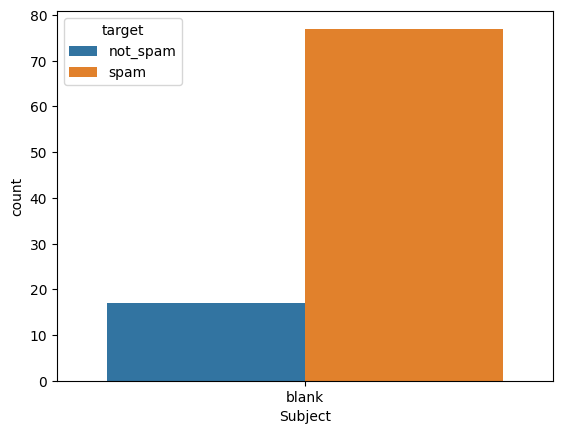

In [88]:
sns.countplot(x=no_contentdf['Subject'], hue=no_contentdf['target'])
plt.show()

<h4><font face=verdona>We know blank mails are mostly send with attachments and non formal mails , not spam mails and the graph supports our understanding, also since the other features play important role with respect to independent variable we can't drop these records.

In [89]:
spam_data['target'] = spam_data['target'].map({ 'not_spam' : 0, 'spam' : 1})

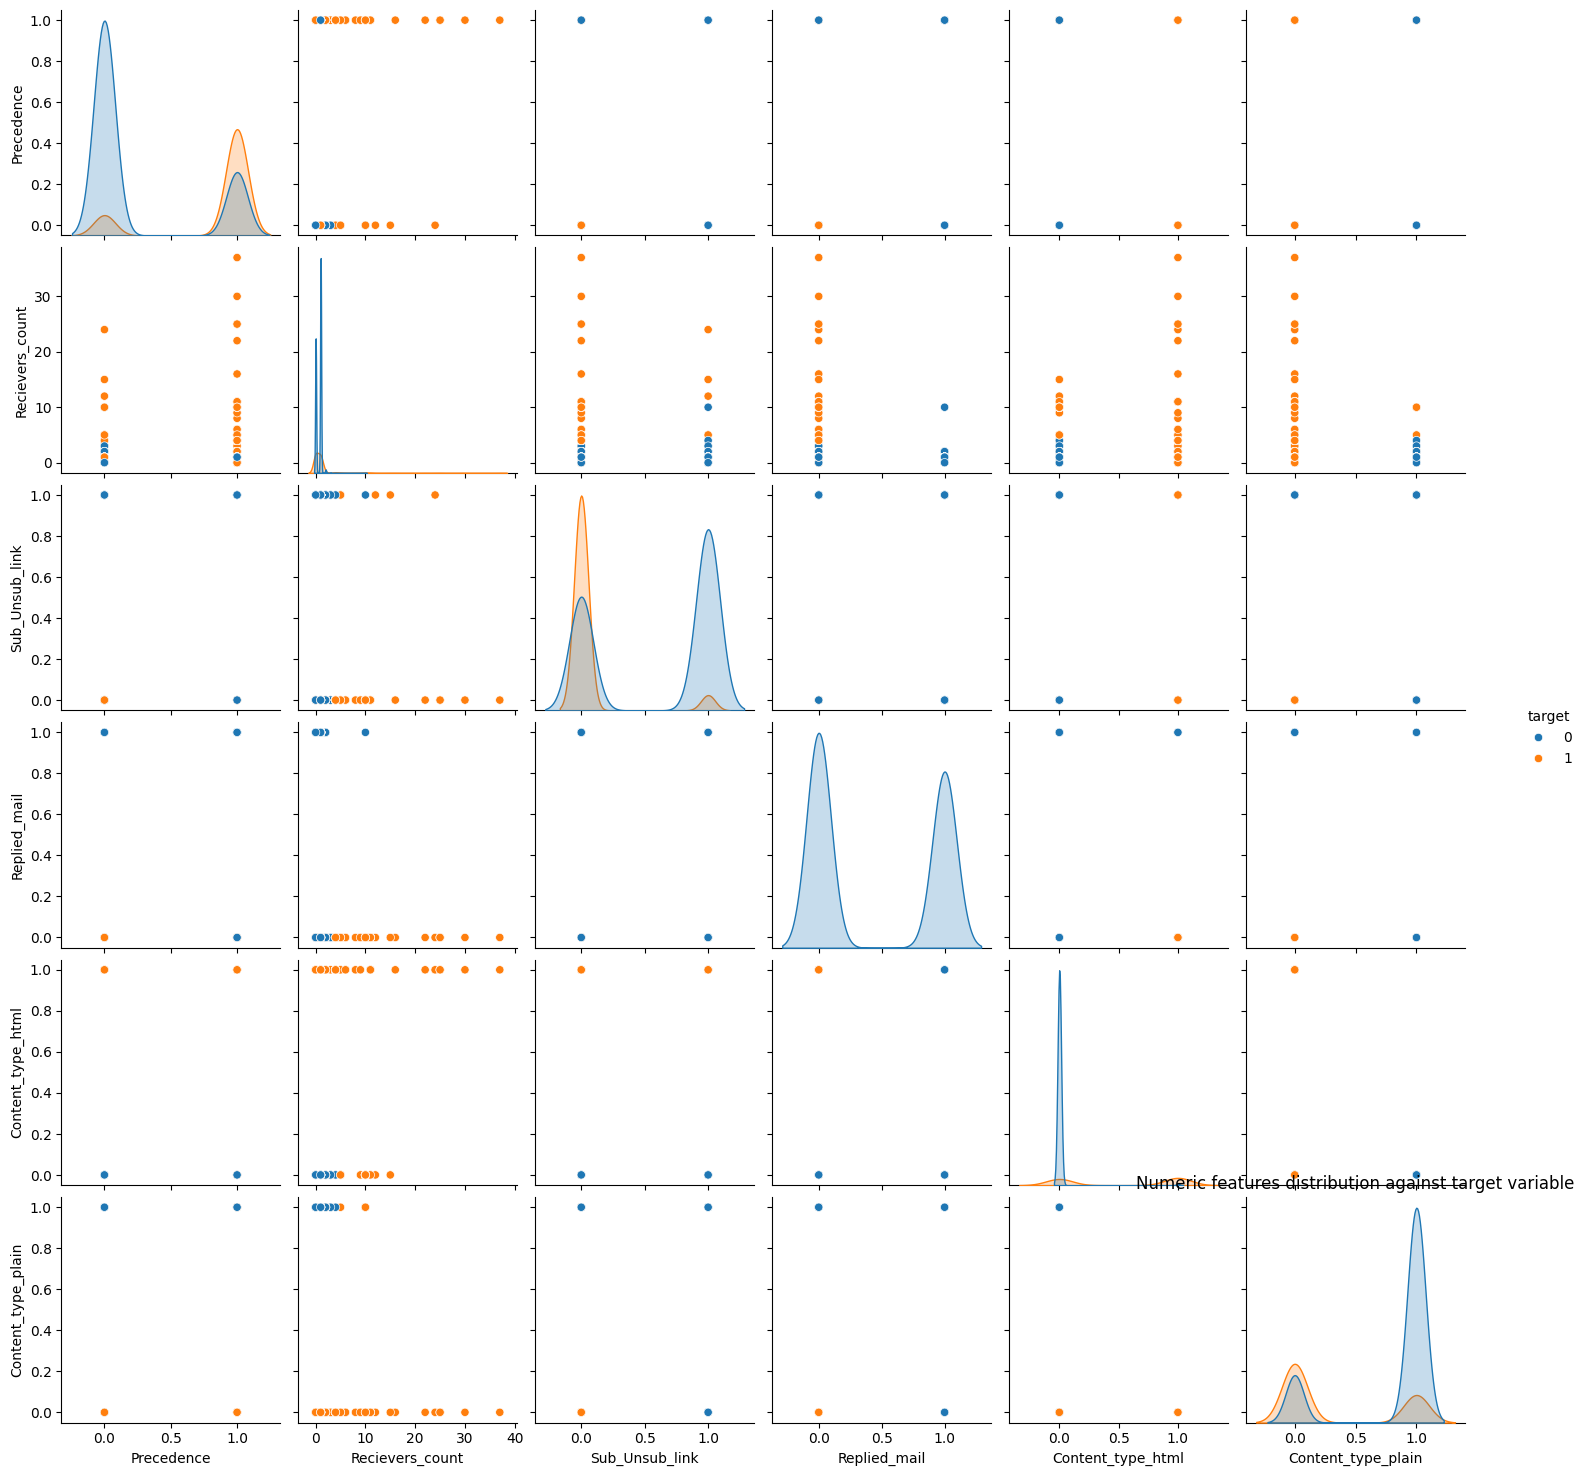

In [90]:
sns.pairplot(spam_data.select_dtypes(include=[int, float]), hue='target')
plt.title("Numeric features distribution against target variable")
plt.show()

<h4><font face=verdona><b>Observation:</b><br>We can see in binary  feature each category is associated with one class of the target variable.

In [91]:
spam_data['content_char'] = spam_data['Full_content'].apply(len)
spam_data['sub_char'] = spam_data['Subject'].apply(len)
spam_data

,target,Subject,Precedence,Recievers_count,Sub_Unsub_link,Replied_mail,Content_type_html,Content_type_plain,Full_content,content_char,sub_char
0,0,ilug architecture crossover trouble w rh solved,0,0,0,1,0,1,blank,5,47
1,1,cash in on your home equity,1,0,0,0,0,1,mortgage lenders brokers are ready to compete ...,863,27
2,1,are your mortgage rates the best they can be l...,0,0,1,0,0,1,dear homeowner interest rates are at their low...,647,56
3,1,online approval for now,1,1,0,0,1,0,free card search sincerely your new offers sta...,55,23
4,0,ilug expanding a string multiple times,0,1,0,1,0,1,blank,5,38
...,...,...,...,...,...,...,...,...,...,...,...
5324,0,ilug nmap results i had posted previously abou...,0,0,0,0,0,1,blank,5,390
5325,0,the absurdities of life,0,1,1,1,0,1,so i get a check from pac bell today sbc as th...,1107,23
5326,1,real drugs viagra and phentrimine,0,1,0,0,1,0,blank,5,33
5327,0,home based business for grownups sep check,0,0,1,1,0,1,use the sample spam txt from spamassassin and ...,429,42


In [92]:
spam_data.describe()

,target,Precedence,Recievers_count,Sub_Unsub_link,Replied_mail,Content_type_html,Content_type_plain,content_char,sub_char
count,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000
mean,0.317320,0.421843,0.698442,0.440420,0.307562,0.175830,0.660537,442.133233,55.182023
std,0.465477,0.493900,1.302169,0.496484,0.461528,0.380711,0.473572,1108.479406,238.098951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,17.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,155.000000,27.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,526.000000,39.000000
max,1.000000,1.000000,37.000000,1.000000,1.000000,1.000000,1.000000,36606.000000,6860.000000


In [93]:
spam_data

,target,Subject,Precedence,Recievers_count,Sub_Unsub_link,Replied_mail,Content_type_html,Content_type_plain,Full_content,content_char,sub_char
0,0,ilug architecture crossover trouble w rh solved,0,0,0,1,0,1,blank,5,47
1,1,cash in on your home equity,1,0,0,0,0,1,mortgage lenders brokers are ready to compete ...,863,27
2,1,are your mortgage rates the best they can be l...,0,0,1,0,0,1,dear homeowner interest rates are at their low...,647,56
3,1,online approval for now,1,1,0,0,1,0,free card search sincerely your new offers sta...,55,23
4,0,ilug expanding a string multiple times,0,1,0,1,0,1,blank,5,38
...,...,...,...,...,...,...,...,...,...,...,...
5324,0,ilug nmap results i had posted previously abou...,0,0,0,0,0,1,blank,5,390
5325,0,the absurdities of life,0,1,1,1,0,1,so i get a check from pac bell today sbc as th...,1107,23
5326,1,real drugs viagra and phentrimine,0,1,0,0,1,0,blank,5,33
5327,0,home based business for grownups sep check,0,0,1,1,0,1,use the sample spam txt from spamassassin and ...,429,42


<h4><font face=verdona color=yellow>Scaling features using MinMaxScaler to scale within 0 to 1 range

In [94]:
from sklearn.preprocessing import MinMaxScaler
rec_cnt_scaler = MinMaxScaler((0,1))
recievers_cnt = rec_cnt_scaler.fit_transform(spam_data[['Recievers_count']])
spam_data['Recievers_count'] = recievers_cnt

In [95]:
sub_char_scaler = MinMaxScaler((0,1))
sub_char = sub_char_scaler.fit_transform(spam_data[['sub_char']])
spam_data['sub_char'] = sub_char

In [96]:
content_char_scaler = MinMaxScaler((0,1))
cont_char = content_char_scaler.fit_transform(spam_data[['content_char']])
spam_data['content_char'] = cont_char

In [97]:
spam_data.describe()

,target,Precedence,Recievers_count,Sub_Unsub_link,Replied_mail,Content_type_html,Content_type_plain,content_char,sub_char
count,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000,5329.000000
mean,0.317320,0.421843,0.018877,0.440420,0.307562,0.175830,0.660537,0.012051,0.007755
std,0.465477,0.493900,0.035194,0.496484,0.461528,0.380711,0.473572,0.030282,0.034718
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000109,0.002187
50%,0.000000,0.000000,0.027027,0.000000,0.000000,0.000000,1.000000,0.004207,0.003645
75%,1.000000,1.000000,0.027027,1.000000,1.000000,0.000000,1.000000,0.014342,0.005395
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


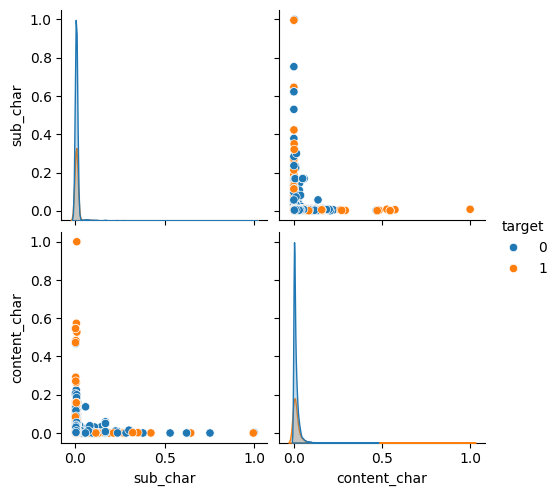

In [98]:
sns.pairplot(data=spam_data[['sub_char', 'content_char', 'target']], hue='target')
plt.show()

In [99]:
spam_data.isnull().sum()

target                0
Subject               0
Precedence            0
Recievers_count       0
Sub_Unsub_link        0
Replied_mail          0
Content_type_html     0
Content_type_plain    0
Full_content          0
content_char          0
sub_char              0
dtype: int64

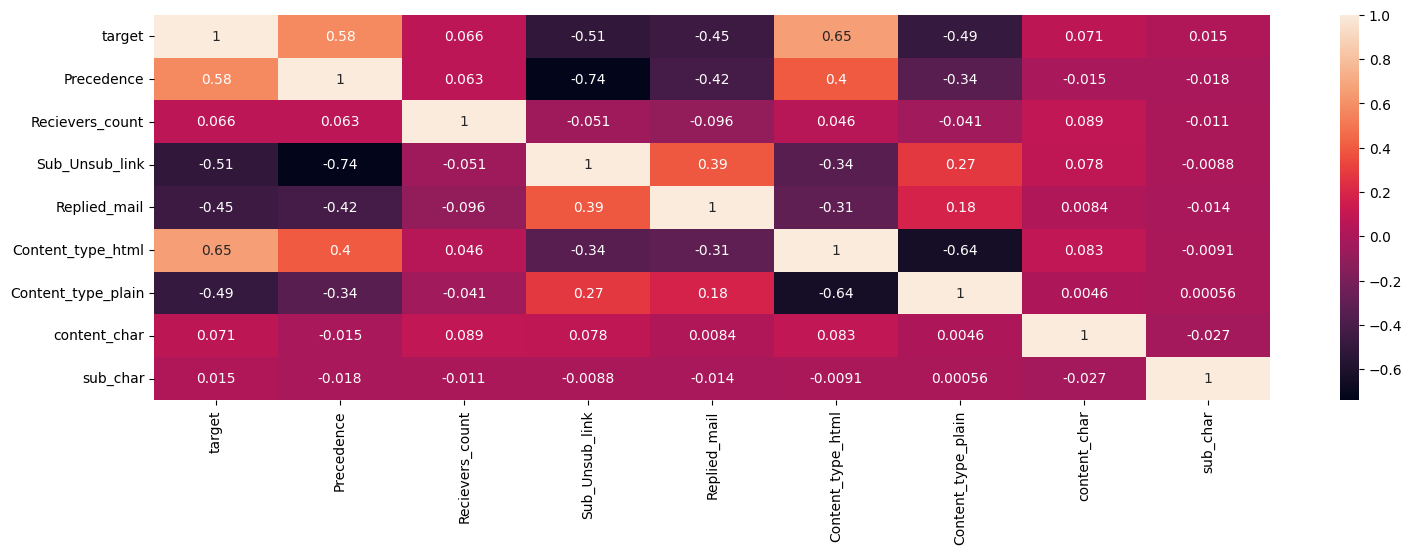

In [100]:
plt.figure(figsize=(18,5))
sns.heatmap(spam_data.corr(numeric_only=True), annot=True)
plt.show()

In [101]:
spam = spam_data[(spam_data['target'] == 1) & (spam_data['Subject'] != "blank")]
not_spam = spam_data[(spam_data['target']==0) & (spam_data['Subject'] != "blank")]

In [102]:
spam.describe()

,target,Precedence,Recievers_count,Sub_Unsub_link,Replied_mail,Content_type_html,Content_type_plain,content_char,sub_char
count,1540.0,1540.000000,1540.000000,1540.000000,1540.0,1540.000000,1540.000000,1540.000000,1540.000000
mean,1.0,0.829870,0.022113,0.071429,0.0,0.549351,0.331169,0.015423,0.009296
std,0.0,0.375869,0.056933,0.257623,0.0,0.497720,0.470787,0.045738,0.039889
min,1.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000082,0.000000
25%,1.0,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000109,0.002770
50%,1.0,1.000000,0.013514,0.000000,0.0,1.000000,0.000000,0.005191,0.004229
75%,1.0,1.000000,0.027027,0.000000,0.0,1.000000,1.000000,0.016343,0.005687
max,1.0,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,0.995626


In [103]:
not_spam.describe()

,target,Precedence,Recievers_count,Sub_Unsub_link,Replied_mail,Content_type_html,Content_type_plain,content_char,sub_char
count,3565.0,3565.000000,3565.000000,3565.000000,3565.000000,3565.000000,3565.000000,3565.000000,3565.000000
mean,0.0,0.226087,0.017164,0.612903,0.454698,0.006171,0.821318,0.010479,0.007549
std,0.0,0.418355,0.013793,0.487154,0.498013,0.078325,0.383139,0.018755,0.033323
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000109,0.002333
50%,0.0,0.000000,0.027027,1.000000,0.000000,0.000000,1.000000,0.003989,0.003500
75%,0.0,0.000000,0.027027,1.000000,1.000000,0.000000,1.000000,0.013741,0.005395
max,0.0,1.000000,0.108108,1.000000,1.000000,1.000000,1.000000,0.468215,1.000000


<h3><font color=yellow face=verdona><hr>Building Wordcloud of Spam Records and Not Spam Records<hr>

In [104]:
from wordcloud import WordCloud

In [105]:
def generate_wc(data, title):
    all_text = ' '.join(data)
    wc = WordCloud(width=800, height=400, background_color='white').generate(all_text)
    plt.figure(figsize=(18, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(font='georgia',label=f'{title}')
    plt.axis('off')
    plt.show()

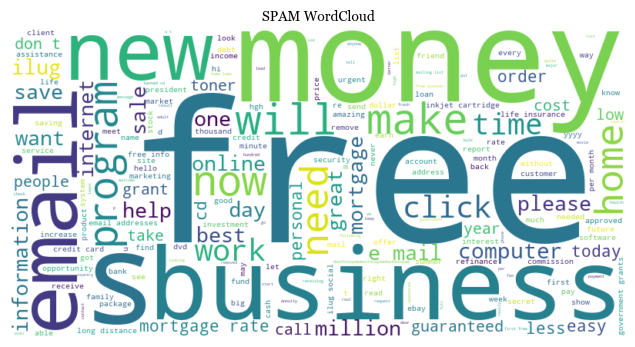

In [106]:
generate_wc(spam['Subject'],'SPAM WordCloud')

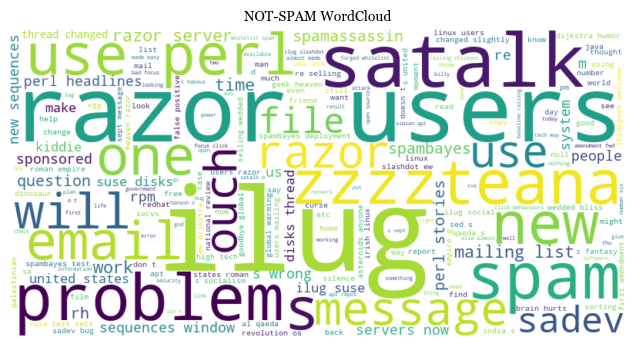

In [107]:
generate_wc(not_spam['Subject'],'NOT-SPAM WordCloud')

<center><div style="background-color: brown"><h1><font color=white face="georgia">Text Proprocessing

In [108]:
# Uncomment these while initial running 
# nltk.download('stopwords')
# nltk.download('wordnet')

<h3><font face=verdona>
Tokenization, Lowercasing, Removing punctuation, special characters and stop words, Stemming

In [109]:
spam_data['Subject'] = spam_data['Subject'].apply(lambda x: "blank" if x.strip() == "" else x)
spam_data['Full_content'] = spam_data['Full_content'].apply(lambda x: "blank" if x.strip() == "" else x)

In [110]:
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer('english')
stop_words = set(stopwords.words('english'))

def preprocessing_text(text, stopwords=stop_words):
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stopwords]
    return ' '.join(words)

In [111]:
preprocessed_df = spam_data.copy()
preprocessed_df['Subject'] = preprocessed_df['Subject'].apply(preprocessing_text)
preprocessed_df['Full_content'] = preprocessed_df['Full_content'].apply(preprocessing_text)
preprocessed_df

,target,Subject,Precedence,Recievers_count,Sub_Unsub_link,Replied_mail,Content_type_html,Content_type_plain,Full_content,content_char,sub_char
0,0,ilug architectur crossov troubl w rh solv,0,0.000000,0,1,0,1,blank,0.000109,0.006562
1,1,cash home equiti,1,0.000000,0,0,0,1,mortgag lender broker readi compet busi whethe...,0.023549,0.003645
2,1,mortgag rate best lkvt rfxd c,0,0.000000,1,0,0,1,dear homeown interest rate lowest point year h...,0.017648,0.007874
3,1,onlin approv,1,0.027027,0,0,1,0,free card search sincer new offer staff remov,0.001475,0.003062
4,0,ilug expand string multipl time,0,0.027027,0,1,0,1,blank,0.000109,0.005249
...,...,...,...,...,...,...,...,...,...,...,...
5324,0,ilug nmap result post previous kernel use ipta...,0,0.000000,0,0,0,1,blank,0.000109,0.056576
5325,0,absurd life,0,0.027027,1,1,0,1,get check pac bell today sbc call turn went tr...,0.030214,0.003062
5326,1,real drug viagra phentrimin,0,0.027027,0,0,1,0,blank,0.000109,0.004520
5327,0,home base busi grownup sep check,0,0.000000,1,1,0,1,use sampl spam txt spamassassin razor check sa...,0.011692,0.005833


In [112]:
preprocessed_df.to_csv('datasets/preprocessed_df.csv')
preprocessed_df = pd.read_csv('datasets/preprocessed_df.csv',index_col=0)
preprocessed_df

,target,Subject,Precedence,Recievers_count,Sub_Unsub_link,Replied_mail,Content_type_html,Content_type_plain,Full_content,content_char,sub_char
0,0,ilug architectur crossov troubl w rh solv,0,0.000000,0,1,0,1,blank,0.000109,0.006562
1,1,cash home equiti,1,0.000000,0,0,0,1,mortgag lender broker readi compet busi whethe...,0.023549,0.003645
2,1,mortgag rate best lkvt rfxd c,0,0.000000,1,0,0,1,dear homeown interest rate lowest point year h...,0.017648,0.007874
3,1,onlin approv,1,0.027027,0,0,1,0,free card search sincer new offer staff remov,0.001475,0.003062
4,0,ilug expand string multipl time,0,0.027027,0,1,0,1,blank,0.000109,0.005249
...,...,...,...,...,...,...,...,...,...,...,...
5324,0,ilug nmap result post previous kernel use ipta...,0,0.000000,0,0,0,1,blank,0.000109,0.056576
5325,0,absurd life,0,0.027027,1,1,0,1,get check pac bell today sbc call turn went tr...,0.030214,0.003062
5326,1,real drug viagra phentrimin,0,0.027027,0,0,1,0,blank,0.000109,0.004520
5327,0,home base busi grownup sep check,0,0.000000,1,1,0,1,use sampl spam txt spamassassin razor check sa...,0.011692,0.005833


<h3><font face=verdona>
Tokenization Removing stop words and Lemmatizing

In [113]:
lem = WordNetLemmatizer()
def preprocessing_text2(text, stopwords=stop_words):
    words = text.split()
    words = [lem.lemmatize(word) for word in words if ((word not in stopwords) and (len(str(word)) > 1)) ]
    words = [word for word in words if len(word) > 1]
    return ' '.join(words)

In [114]:
preprocessed_df2 = spam_data.copy()
preprocessed_df2['Subject'] = preprocessed_df2['Subject'].apply(preprocessing_text2)
preprocessed_df2['Full_content'] = preprocessed_df2['Full_content'].apply(preprocessing_text2)
preprocessed_df2

,target,Subject,Precedence,Recievers_count,Sub_Unsub_link,Replied_mail,Content_type_html,Content_type_plain,Full_content,content_char,sub_char
0,0,ilug architecture crossover trouble rh solved,0,0.000000,0,1,0,1,blank,0.000109,0.006562
1,1,cash home equity,1,0.000000,0,0,0,1,mortgage lender broker ready compete business ...,0.023549,0.003645
2,1,mortgage rate best lkvt rfxd,0,0.000000,1,0,0,1,dear homeowner interest rate lowest point year...,0.017648,0.007874
3,1,online approval,1,0.027027,0,0,1,0,free card search sincerely new offer staff remove,0.001475,0.003062
4,0,ilug expanding string multiple time,0,0.027027,0,1,0,1,blank,0.000109,0.005249
...,...,...,...,...,...,...,...,...,...,...,...
5324,0,ilug nmap result posted previously kernel usin...,0,0.000000,0,0,0,1,blank,0.000109,0.056576
5325,0,absurdity life,0,0.027027,1,1,0,1,get check pac bell today sbc called turn went ...,0.030214,0.003062
5326,1,real drug viagra phentrimine,0,0.027027,0,0,1,0,blank,0.000109,0.004520
5327,0,home based business grownup sep check,0,0.000000,1,1,0,1,use sample spam txt spamassassin razor check s...,0.011692,0.005833


In [115]:
preprocessed_df2.to_csv('datasets/preprocessed_df2.csv')
preprocessed_df2 = pd.read_csv('datasets/preprocessed_df2.csv',index_col=0)
preprocessed_df2

,target,Subject,Precedence,Recievers_count,Sub_Unsub_link,Replied_mail,Content_type_html,Content_type_plain,Full_content,content_char,sub_char
0,0,ilug architecture crossover trouble rh solved,0,0.000000,0,1,0,1,blank,0.000109,0.006562
1,1,cash home equity,1,0.000000,0,0,0,1,mortgage lender broker ready compete business ...,0.023549,0.003645
2,1,mortgage rate best lkvt rfxd,0,0.000000,1,0,0,1,dear homeowner interest rate lowest point year...,0.017648,0.007874
3,1,online approval,1,0.027027,0,0,1,0,free card search sincerely new offer staff remove,0.001475,0.003062
4,0,ilug expanding string multiple time,0,0.027027,0,1,0,1,blank,0.000109,0.005249
...,...,...,...,...,...,...,...,...,...,...,...
5324,0,ilug nmap result posted previously kernel usin...,0,0.000000,0,0,0,1,blank,0.000109,0.056576
5325,0,absurdity life,0,0.027027,1,1,0,1,get check pac bell today sbc called turn went ...,0.030214,0.003062
5326,1,real drug viagra phentrimine,0,0.027027,0,0,1,0,blank,0.000109,0.004520
5327,0,home based business grownup sep check,0,0.000000,1,1,0,1,use sample spam txt spamassassin razor check s...,0.011692,0.005833


In [116]:
preprocessed_df.fillna("blank", inplace=True)
preprocessed_df2.fillna("blank", inplace=True)

<h3><font color=blue face=verdona><center>Plotting the 30 most frequent words used in Spam and not spam Emails

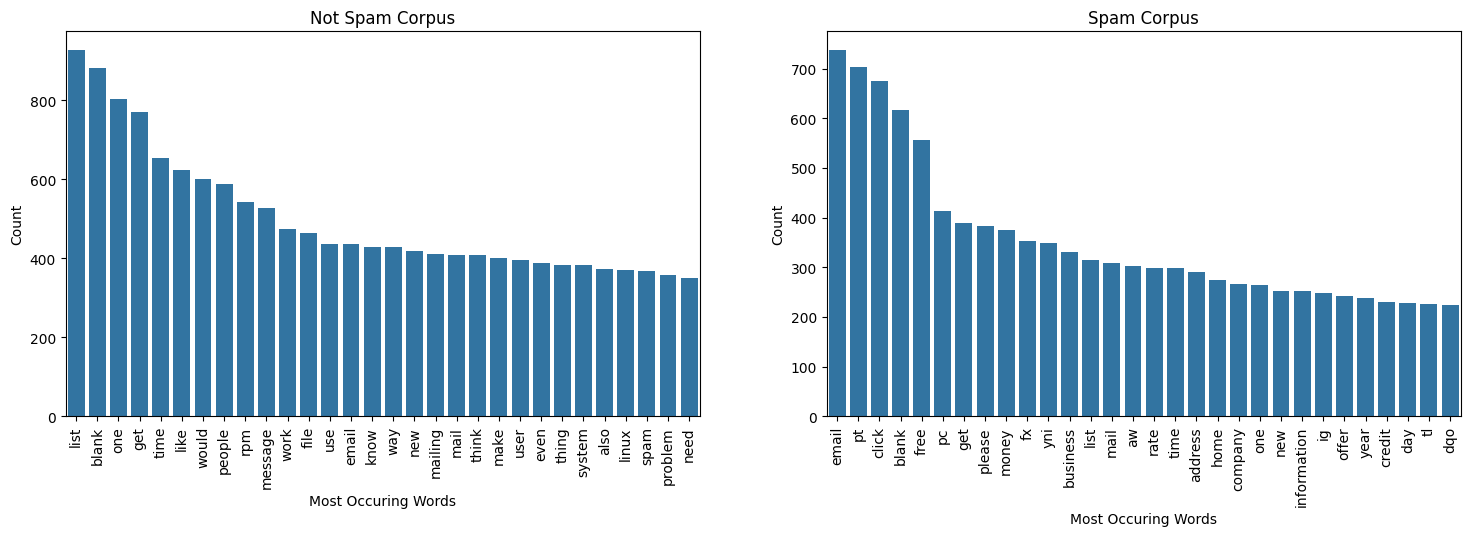

In [117]:
import warnings 
warnings.filterwarnings('ignore')

spam_corpus = []
not_spam_corpus = []
for index, text in enumerate(preprocessed_df2['Full_content']):
    if preprocessed_df2['target'][index] == 0:
        not_spam_corpus.extend(text.split())
    else:
        spam_corpus.extend(text.split())

from collections import Counter
corpuses = [not_spam_corpus, spam_corpus]
corpus_names = ['Not Spam Corpus', 'Spam Corpus']
fig , ax = plt.subplots(nrows=1, ncols=2, figsize=(18,5))
axes = ax.flatten()
for i in range(2):
    sns.barplot(x=pd.DataFrame(Counter(corpuses[i]).most_common(30))[0], 
                y=pd.DataFrame(Counter(corpuses[i]).most_common(30))[1], ax=axes[i])
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation='vertical')
    axes[i].set_xlabel('Most Occuring Words')
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'{corpus_names[i]}')
plt.show()

In [118]:
print(Counter(corpuses[1]).most_common(30))

[('email', 738), ('pt', 704), ('click', 675), ('blank', 616), ('free', 556), ('pc', 413), ('get', 390), ('please', 384), ('money', 376), ('fx', 353), ('yni', 349), ('business', 331), ('list', 315), ('mail', 308), ('aw', 303), ('rate', 299), ('time', 298), ('address', 291), ('home', 274), ('company', 267), ('one', 264), ('new', 253), ('information', 253), ('ig', 248), ('offer', 243), ('year', 239), ('credit', 231), ('day', 228), ('tl', 226), ('dqo', 224)]


<h4><font face=verdona> The corpuses are not having a good understanding of the as the solid content of the data is unstructured though lot of useful information has still be extracted

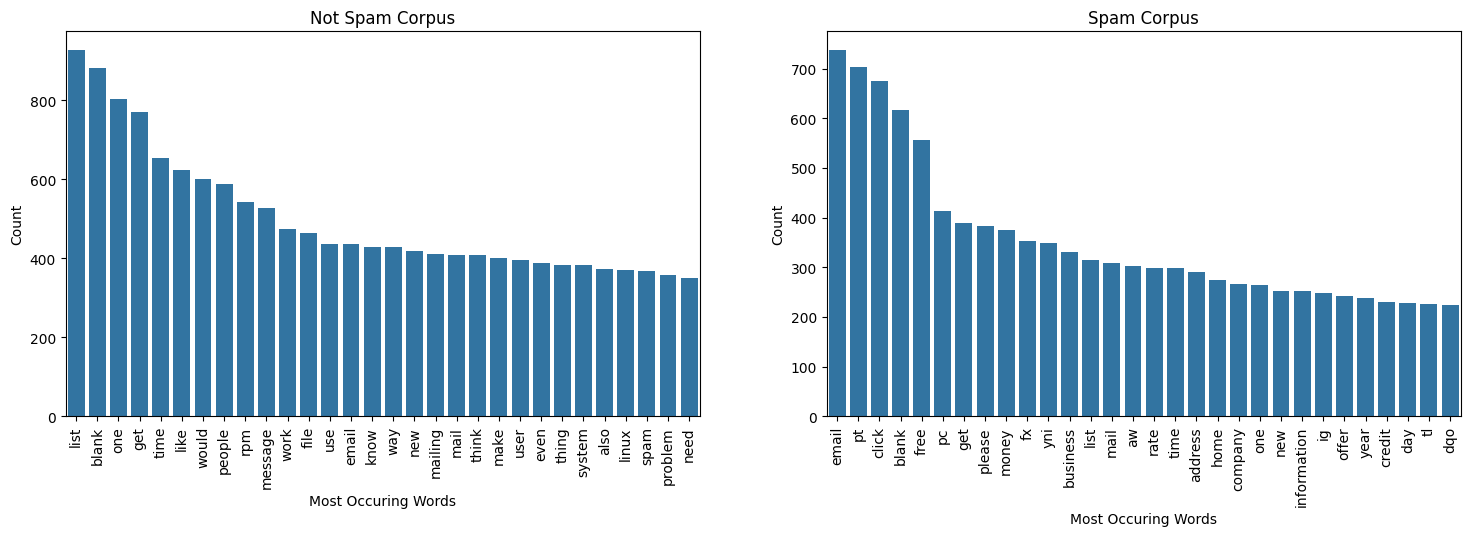

In [119]:
import warnings 
warnings.filterwarnings('ignore')

spam_corpus = []
not_spam_corpus = []
for index, text in enumerate(preprocessed_df2['Full_content']):
    if preprocessed_df2['target'][index] == 0:
        not_spam_corpus.extend(text.split())
    else:
        spam_corpus.extend(text.split())

from collections import Counter
corpuses = [not_spam_corpus, spam_corpus]
corpus_names = ['Not Spam Corpus', 'Spam Corpus']
fig , ax = plt.subplots(nrows=1, ncols=2, figsize=(18,5))
axes = ax.flatten()
for i in range(2):
    sns.barplot(x=pd.DataFrame(Counter(corpuses[i]).most_common(30))[0], 
                y=pd.DataFrame(Counter(corpuses[i]).most_common(30))[1], ax=axes[i])
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation='vertical')
    axes[i].set_xlabel('Most Occuring Words')
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'{corpus_names[i]}')
plt.show()

<h3><font color=yellow face=verdona><center> Vectorization

In [120]:
# cv_content = CountVectorizer(max_features=3000)
# cv_subject = CountVectorizer(max_features=3000)
tfidf_content = TfidfVectorizer(max_features=3000)
tfidf_subject = TfidfVectorizer(max_features=3000)

In [121]:
# content_vectors = cv_content.fit_transform(preprocessed_df['Full_content']).toarray()
# subject_vectors = cv_subject.fit_transform(preprocessed_df['Subject']).toarray()
content_vectors = tfidf_content.fit_transform(preprocessed_df['Full_content']).toarray()
subject_vectors = tfidf_subject.fit_transform(preprocessed_df['Subject']).toarray()

In [122]:
print(content_vectors.shape, subject_vectors.shape)

(5329, 3000) (5329, 3000)


In [123]:
vec_array = np.concatenate((content_vectors, subject_vectors), axis=1)
vec_array

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [124]:
print(vec_array.shape)

(5329, 6000)


In [125]:
X = vec_array
X.shape

(5329, 6000)

In [126]:
y = preprocessed_df['target'].values
y.shape

(5329,)

In [127]:
X_trimmed = X[:-10, :]
y_trimmed = y[:-10]

<center><div style="background-color: brown"><h1><font color=white face="georgia">Train Test Split<br>
    Various Models Training and Evaluation

<h3><font face=verdona> Training models only on<font color=yellow> text</font> features

Some models were commented out because of their high time complexity

In [128]:
# pca = PCA(n_components=10)

# These models are commented out considering Time complexity
# gb = GradientBoostingClassifier()
# rforest = RandomForestClassifier(class_weight='balanced') 
# svc = SVC(kernel='linear')
# xgb = XGBClassifier(scale_pos_weight=3)
# xgbrf = XGBRFClassifier(scale_pos_weight=5)

dtree = DecisionTreeClassifier(class_weight='balanced',min_samples_leaf=15)
lgb_model = LGBMClassifier(class_weight='balanced', verbose=-1)
knc = KNeighborsClassifier(weights='uniform')
l_reg = LogisticRegression(class_weight='balanced')
mnb = MultinomialNB(class_prior=[0.5,0.5])
gnb = GaussianNB(priors=[0.5,0.5])

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

models = [dtree, lgb_model, knc, l_reg, gnb, mnb ] #,rforest, xgb, xgbrf, svc, gb]
model_names = ['DTree', 'LightGBM', 'KNNeighbors','Logistic Regression', 'GNB', 'MNB']
            #    , 'RForest', 'XGBoost', 'XGBRF', 'SVC', 'Gradient Boosting']

best_models = {}
models_mean_scores = {}

for i, model in enumerate(models):
    model_name = model_names[i]
    best_recall = 0.0

    print(f'\n\t\t\t\t{model_name}')
    results = []

    for train_indices, test_indices in kfold.split(X_trimmed):     
        start = time.time()       
        X_train, X_test, y_train, y_test = X_trimmed[train_indices], X_trimmed[test_indices], y_trimmed[train_indices], y_trimmed[test_indices]
        # X_train = pca.fit_transform(X_train)

        model.fit(X_train, y_train)

        # X_test = pca.transform(X_test)
        y_pred_cm = model.predict(X_test)#[:, 1]

        # y_pred_cm = np.where(y_pred > 0.5, 1, 0)
        acc_scr = accuracy_score(y_test, y_pred_cm)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cm).ravel()
        specificity = round(tn / (tn + fp), 2)

        recall = recall_score(y_test, y_pred_cm)
        time_elapsed = time.time() - start

        results.append({
            'Specificity (TNR)' : specificity, # True Negative Rate 
            'Recall (TPR)' : round(recall, 3),
            'Accuracy': round(acc_scr, 3),
            'Time Taken (s)': round(time_elapsed, 2)
        })

        if recall > best_recall:
            best_accuracy = recall
            best_models[model_name] = {
                'Model': model
            }

    models_mean_scores[model_name] = {
        'Recall (TPR)' : np.mean([r['Recall (TPR)'] for r in results]),
        'Specificity (TNR)' : np.mean([r['Specificity (TNR)'] for r in results]),
        }

    results_df = pd.DataFrame(results)

    print(results_df.to_string(index=False))
    print("-" * 80)
    print(f'Mean:\t     {round(results_df['Specificity (TNR)'].mean(),
                                3)}\t   {round(results_df['Recall (TPR)'].mean(), 
                                3)}\t  {round(results_df["Accuracy"].mean(), 
                                3)}\t\t   {round(results_df['Time Taken (s)'].mean(), 2)}')


				DTree
 Specificity (TNR)  Recall (TPR)  Accuracy  Time Taken (s)
              0.85         0.848     0.847            9.36
              0.81         0.875     0.829            9.76
              0.82         0.870     0.838            9.26
              0.81         0.855     0.820            9.36
              0.83         0.886     0.851            7.07
--------------------------------------------------------------------------------
Mean:	     0.824	   0.867	  0.837		   8.96

				LightGBM
 Specificity (TNR)  Recall (TPR)  Accuracy  Time Taken (s)
              0.92         0.916     0.922            3.16
              0.91         0.917     0.915            2.32
              0.92         0.924     0.918            2.41
              0.90         0.925     0.911            2.43
              0.92         0.912     0.916            2.47
--------------------------------------------------------------------------------
Mean:	     0.914	   0.919	  0.916		   2.56

				KNNeighbors
 S

<h3><font face=verdona>Training models only on <font color=yellow> numeric</font> features

In [129]:
spam.select_dtypes(include=[int, float]).columns

Index(['target', 'Precedence', 'Recievers_count', 'Sub_Unsub_link',
       'Replied_mail', 'Content_type_html', 'Content_type_plain',
       'content_char', 'sub_char'],
      dtype='object')

In [130]:
X_2 = spam_data[['Replied_mail', 'Recievers_count', 'Sub_Unsub_link',
       'Content_type_html', 'Content_type_plain', 'content_char', 'sub_char',]]
X_2 = X_2.to_numpy()
X_2.shape

(5329, 7)

In [131]:
X_2_trimmed = X_2[:-10, :]

In [132]:
# pca = PCA(n_components=10)

dtree = DecisionTreeClassifier(class_weight='balanced',min_samples_leaf=15)
lgb_model = LGBMClassifier(class_weight='balanced', verbose=-1)
knc = KNeighborsClassifier(weights='uniform')
l_reg = LogisticRegression(class_weight='balanced')
mnb = MultinomialNB(class_prior=[0.5,0.5])
gnb = GaussianNB(priors=[0.5,0.5])

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

models = [dtree, lgb_model, knc, l_reg, gnb, mnb ]
model_names = ['DTree', 'LightGBM', 'KNNeighbors','Logistic Regression', 'GNB', 'MNB']

best_models = {}
models_mean_scores = {}

for i, model in enumerate(models):
    model_name = model_names[i]
    best_recall = 0.0

    print(f'\n\t\t\t\t{model_name}')
    results = []

    for train_indices, test_indices in kfold.split(X_2_trimmed):            
        start = time.time()
        X_train, X_test, y_train, y_test = X_2_trimmed[train_indices], X_2_trimmed[test_indices], y_trimmed[train_indices], y_trimmed[test_indices]
        # X_train = pca.fit_transform(X_train)
        
        model.fit(X_train, y_train)

        # X_test = pca.transform(X_test)
        y_pred_cm = model.predict(X_test)#[:, 1]

        # y_pred_cm = np.where(y_pred > 0.5, 1, 0)
        acc_scr = accuracy_score(y_test, y_pred_cm)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cm).ravel()
        specificity = round(tn / (tn + fp), 2)

        recall = recall_score(y_test, y_pred_cm)
        time_elapsed = time.time() - start

        results.append({
            'Specificity (TNR)' : specificity, # True Negative Rate 
            'Recall (TPR)' : round(recall, 3),
            'Accuracy': round(acc_scr, 3),
            'Time Taken (s)': round(time_elapsed, 2)
        })

        if recall > best_recall:
            best_accuracy = recall
            best_models[model_name] = {
                'Model': model
            }

    models_mean_scores[model_name] = {
        'Recall (TPR)' : np.mean([r['Recall (TPR)'] for r in results]),
        'Specificity (TNR)' : np.mean([r['Specificity (TNR)'] for r in results]),
        }

    results_df = pd.DataFrame(results)

    print(results_df.to_string(index=False))
    print("-" * 80)
    print(f'Mean:\t     {round(results_df['Specificity (TNR)'].mean(),
                                3)}\t   {round(results_df['Recall (TPR)'].mean(), 
                                3)}\t  {round(results_df["Accuracy"].mean(), 
                                3)}\t\t   {round(results_df['Time Taken (s)'].mean(), 2)}')


				DTree
 Specificity (TNR)  Recall (TPR)  Accuracy  Time Taken (s)
              0.90         0.899     0.897            0.05
              0.88         0.889     0.886            0.01
              0.92         0.885     0.907            0.01
              0.90         0.868     0.893            0.02
              0.89         0.898     0.895            0.02
--------------------------------------------------------------------------------
Mean:	     0.898	   0.888	  0.896		   0.02

				LightGBM
 Specificity (TNR)  Recall (TPR)  Accuracy  Time Taken (s)
              0.91         0.913     0.913            0.43
              0.89         0.915     0.896            0.16
              0.91         0.897     0.907            0.13
              0.93         0.887     0.915            0.11
              0.91         0.898     0.907            0.11
--------------------------------------------------------------------------------
Mean:	     0.91	   0.902	  0.908		   0.19

				KNNeighbors
 Sp

<h3><font face=verdona>We have extracted very good numeric features from the texts which without even the text have good accuracy to if an email is spam or ham.

In [133]:
final_X = np.concatenate((X, X_2), axis=1)
print(final_X.shape)
final_X

(5329, 6007)


array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.00000000e+00, 1.09274689e-04, 6.56167979e-03],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.00000000e+00, 2.35486955e-02, 3.64537766e-03],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.00000000e+00, 1.76478623e-02, 7.87401575e-03],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.09274689e-04, 4.52026830e-03],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.00000000e+00, 1.16923917e-02, 5.83260426e-03],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.00000000e+00, 2.84114192e-03, 3.20793234e-03]])

In [134]:
y = preprocessed_df['target'].values
y.shape

(5329,)

In [135]:
final_X_trimmed = final_X[:-10, :]

In [136]:
dtree = DecisionTreeClassifier(class_weight='balanced',min_samples_leaf=15)
lgb_model = LGBMClassifier(class_weight='balanced', verbose=-1)
knc = KNeighborsClassifier(weights='uniform')
l_reg = LogisticRegression(class_weight='balanced')
mnb = MultinomialNB(class_prior=[0.5,0.5])
gnb = GaussianNB(priors=[0.5,0.5])

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

models = [dtree, lgb_model, knc, l_reg, gnb, mnb ]
model_names = ['DTree', 'LightGBM', 'KNNeighbors','Logistic Regression', 'GNB', 'MNB']

best_models = {}
models_mean_scores = {}

for i, model in enumerate(models):
    model_name = model_names[i]
    best_recall = 0.0

    print(f'\n\t\t\t\t{model_name}')
    results = []

    for train_indices, test_indices in kfold.split(final_X_trimmed):            
        start = time.time()
        X_train, X_test, y_train, y_test = final_X_trimmed[train_indices], final_X_trimmed[test_indices], y_trimmed[train_indices], y_trimmed[test_indices]
        # X_train = pca.fit_transform(X_train)
        
        model.fit(X_train, y_train)

        # X_test = pca.transform(X_test)
        y_pred_cm = model.predict(X_test)#[:, 1]

        # y_pred_cm = np.where(y_pred > 0.5, 1, 0)
        acc_scr = accuracy_score(y_test, y_pred_cm)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cm).ravel()
        specificity = round(tn / (tn + fp), 2)

        recall = recall_score(y_test, y_pred_cm)
        time_elapsed = time.time() - start

        results.append({
            'Specificity (TNR)' : specificity, # True Negative Rate 
            'Recall (TPR)' : round(recall, 3),
            'Accuracy': round(acc_scr, 3),
            'Time Taken (s)': round(time_elapsed, 2)
        })

        if recall > best_recall:
            best_accuracy = recall
            best_models[model_name] = {
                # 'Scaler': scaler,
                'Model': model
            }

    models_mean_scores[model_name] = {
        'Recall (TPR)' : np.mean([r['Recall (TPR)'] for r in results]),
        'Specificity (TNR)' : np.mean([r['Specificity (TNR)'] for r in results]),
        }

    results_df = pd.DataFrame(results)

    print(results_df.to_string(index=False))
    print("-" * 80)
    print(f'Mean:\t     {round(results_df['Specificity (TNR)'].mean(),
                                3)}\t   {round(results_df['Recall (TPR)'].mean(), 
                                3)}\t  {round(results_df["Accuracy"].mean(), 
                                3)}\t\t   {round(results_df['Time Taken (s)'].mean(), 2)}')


				DTree
 Specificity (TNR)  Recall (TPR)  Accuracy  Time Taken (s)
              0.94         0.922     0.931            3.99
              0.91         0.917     0.915            3.38
              0.93         0.927     0.930            3.47
              0.93         0.906     0.922            3.14
              0.91         0.918     0.912            3.51
--------------------------------------------------------------------------------
Mean:	     0.924	   0.918	  0.922		   3.5

				LightGBM
 Specificity (TNR)  Recall (TPR)  Accuracy  Time Taken (s)
              0.97         0.931     0.958            2.13
              0.97         0.960     0.966            2.33
              0.98         0.958     0.970            2.07
              0.96         0.943     0.958            1.85
              0.97         0.932     0.959            2.09
--------------------------------------------------------------------------------
Mean:	     0.97	   0.945	  0.962		   2.09

				KNNeighbors
 Spe

<h3><font face=verdona color=yellow>The data is High dimensional data and Neural Networks (DL models) perform comparatively much better on such data.

In [137]:
ip_dim = final_X[-1:, :].shape[1]
import tensorflow as tf

def create_model():
    nn_model = tf.keras.models.Sequential([
        tf.keras.Input(shape=(ip_dim,)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(24, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Recall()])
    return nn_model

In [138]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

results = []  
best_recall = 0.0
best_models = {}
model_name = 'ANN_clf' 

for train_indices, test_indices in kfold.split(final_X_trimmed):            
    start = time.time()
    model = create_model()
    X_train, X_test, y_train, y_test = final_X_trimmed[train_indices], final_X_trimmed[test_indices], y_trimmed[train_indices], y_trimmed[test_indices]
    
    model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)

    
    loss, acc_scr, recall = model.evaluate(X_test, y_test, verbose=0)
    
    y_pred = model.predict(X_test)
    y_pred_cm = np.where(y_pred > 0.5, 1, 0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cm).ravel()
    specificity = tn / (tn + fp)

    time_elapsed = time.time() - start

    results.append({
        'Specificity (TNR)' : round(specificity,3), # True Negative Rate 
        'Recall (TPR)' : round(recall, 3),
        'Accuracy': round(acc_scr, 3),
        'Time Taken (s)': round(time_elapsed, 2)
    })

    if recall > best_recall:
        best_recall = recall
        best_models[model_name] = {
            'Model': model,
            'train_indices' : train_indices,
            'test_indices' : test_indices
        }

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))
print("-" * 80)
print(f'Mean:\t     {round(results_df['Specificity (TNR)'].mean(),
                            3)}\t   {round(results_df['Recall (TPR)'].mean(), 
                            3)}\t  {round(results_df["Accuracy"].mean(), 
                            3)}\t\t   {round(results_df['Time Taken (s)'].mean(), 2)}')

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
 Specificity (TNR)  Recall (TPR)  Accuracy  Time Taken (s)
             0.984         0.955     0.975           14.81
             0.982         0.943     0.969           13.85
             0.980         0.949     0.970           11.47
             0.964         0.947     0.959           11.70
             0.968         0.960     0.965           12.37
--------------------------------------------------------------------------------
Mean:	     0.976	   0.951	  0.968		   12.84


<h3><font color=yellow face=verdona> The ANN model excells all the models in <font color=white>TNR(98%)</font> as well as <font color=white>TPR(95%)</font> with an average of approximately<font color=white> 97% accuracy</font>, Making it the best model

In [139]:
best_models

{'ANN_clf': {'Model': <Sequential name=sequential_4, built=True>,
  'train_indices': array([   0,    1,    2, ..., 5316, 5317, 5318]),
  'test_indices': array([   3,    4,    5, ..., 5302, 5309, 5311])}}

In [140]:
model = best_models['ANN_clf']['Model']
train_indices = best_models['ANN_clf']['train_indices']
test_indices = best_models['ANN_clf']['test_indices']

In [141]:
#fine tuning

X_train_best = final_X_trimmed[train_indices]
y_train_best = y_trimmed[train_indices]

from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

model.fit(X_train_best, y_train_best, epochs=10, batch_size=32, validation_split=0.2, verbose=1, callbacks=[early_stop])

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9978 - loss: 0.0122 - recall_4: 0.9994 - val_accuracy: 0.9765 - val_loss: 0.0831 - val_recall_4: 0.9703
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9955 - loss: 0.0146 - recall_4: 0.9963 - val_accuracy: 0.9777 - val_loss: 0.0895 - val_recall_4: 0.9740
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9977 - loss: 0.0089 - recall_4: 0.9988 - val_accuracy: 0.9765 - val_loss: 0.0870 - val_recall_4: 0.9665


In [142]:
loss, acc_scr, recall = model.evaluate(final_X_trimmed[test_indices], y_trimmed[test_indices], verbose=0)

y_pred = model.predict(final_X_trimmed[test_indices])
y_pred_cm = np.where(y_pred > 0.5, 1, 0)
tn, fp, fn, tp = confusion_matrix(y_trimmed[test_indices], y_pred_cm).ravel()
specificity = tn / (tn + fp)

print(f'After fine tuning : \n Specificity: {round(specificity, 3)}\n Accuracy: {round(acc_scr, 3)}\n Recall: {round(recall, 3)}')

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
After fine tuning : 
 Specificity: 0.968
 Accuracy: 0.962
 Recall: 0.952


<h3><font face=verdona>
Using ANN model to Predict on 10 Unseen rows

In [143]:
preds_l = list()
for row in final_X[-10:,]:
    preds_l.append(model.predict(row.reshape((1, 6007))))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


In [144]:
preds = pd.DataFrame()
preds['Actual'] = list(y[-10:])
preds['Preds'] = [1 if x > 0.5 else 0 for x in preds_l]
preds

,Actual,Preds
0,1,1
1,0,0
2,1,1
3,0,0
4,1,0
5,0,0
6,0,0
7,1,1
8,0,0
9,0,0


<center><div style="background-color: brown"><h1><font color=white face="georgia">Building Pipeline

<h3><font face=verdona color=yellow>Saving Preprocessing Models

In [145]:
# Encoder
with open('feature_encoders/one_hot_encoder.pkl', 'wb')as file:
    pickle.dump(ohe, file)

# Scalers
with open('scalers/rec_cnt_scaler.pkl', 'wb')as file:
    pickle.dump(rec_cnt_scaler, file)
with open('scalers/sub_char_scaler.pkl', 'wb')as file:
    pickle.dump(sub_char_scaler, file)
with open('scalers/content_char_scaler.pkl', 'wb')as file:
    pickle.dump(content_char_scaler, file)

# Tfidf vectorizors
with open('vectorizors/tfidf_content.pkl', 'wb')as file:
    pickle.dump(tfidf_content, file)
with open('vectorizors/tfidf_subject.pkl', 'wb')as file:
    pickle.dump(tfidf_subject, file)

# DL Model
best_models['ANN_clf']['Model'].save("dl_model/ann_model.h5")

In [1]:
import preprocessor
processed_data = preprocessor.pipeline(r'inbox_test_mails\gmail-not_spam.eml', filepath=True)
pred = preprocessor.predictor(processed_data)
pred = round(pred, 2)
print(pred)

INFO:preprocessor:✔️ Libraries imported in 12.2s
INFO:preprocessor:✔️ Pickle files imported in 0.01s
INFO:preprocessor:✔️ DL model imported in 0.18s
INFO:preprocessor:✔️ Email binary file parsing 		0.02s
INFO:preprocessor:✔️ Extracting required features in tabular form 		0.01s
INFO:preprocessor:✔️ Extracting numeric features 		0.01s
INFO:preprocessor:✔️ Encoding categorical features 		0.0s
INFO:preprocessor:✔️ Scaling features not in range (1,0) 		0.0s
INFO:preprocessor:✔️ Lemmatization of text 		4.86s
INFO:preprocessor:✔️ Vectorization of text 		0.0s
INFO:preprocessor:✔️ Concatenating vectors and numeric features 		0.0s
INFO:preprocessor:✔️ Prediction 		0.22s


0.0


In [2]:
processed_data = preprocessor.pipeline(r'inbox_test_mails\gmail-not_spam2.eml', filepath=True)
pred = preprocessor.predictor(processed_data)
pred = round(pred, 2)
print(pred)

INFO:preprocessor:✔️ Email binary file parsing 		0.0s
INFO:preprocessor:✔️ Extracting required features in tabular form 		0.01s
INFO:preprocessor:✔️ Extracting numeric features 		0.02s
INFO:preprocessor:✔️ Encoding categorical features 		0.01s
INFO:preprocessor:✔️ Scaling features not in range (1,0) 		0.02s
INFO:preprocessor:✔️ Lemmatization of text 		0.01s
INFO:preprocessor:✔️ Vectorization of text 		0.0s
INFO:preprocessor:✔️ Concatenating vectors and numeric features 		0.0s
INFO:preprocessor:✔️ Prediction 		0.25s


0.0


In [3]:
processed_data = preprocessor.pipeline(r'inbox_test_mails\gmail-spam.eml', filepath=True)
pred = preprocessor.predictor(processed_data)
pred = round(pred, 2)
print(pred)

INFO:preprocessor:✔️ Email binary file parsing 		0.01s
INFO:preprocessor:✔️ Extracting required features in tabular form 		0.01s
INFO:preprocessor:✔️ Extracting numeric features 		0.03s
INFO:preprocessor:✔️ Encoding categorical features 		0.01s
INFO:preprocessor:✔️ Scaling features not in range (1,0) 		0.03s
INFO:preprocessor:✔️ Lemmatization of text 		0.0s
INFO:preprocessor:✔️ Vectorization of text 		0.0s
INFO:preprocessor:✔️ Concatenating vectors and numeric features 		0.0s
INFO:preprocessor:✔️ Prediction 		0.4s


0.81
